# Supplementary Fig. 12 — position-specific error distributions (20 pre-AML + 20 control, SLX_20124)

## Data availability

This notebook runs the position-specific error model, as the original analysis did. It assembles the
per-position, per-sample matrix for lane SLX_20124 from the pipeline's per-sample DCS all-positions VCFs,
fits a beta-binomial (or a binomial where three or fewer samples carry a variant read) at each of the
~175,000 panel positions, calls real variants at p = 6x10^-6, and plots the resulting error distributions.

The per-sample VCFs are **not distributed with this code**: they give read depth and variant depth for a
named sample at every panel position, germline sites included, so they carry germline genotype
information. They are deposited under controlled access in the European Genome-phenome Archive and
released to approved researchers via a Data Access Committee. Place them in `Data_files/VCF_files/DCS/`,
keeping the filenames unchanged, and set `BUILD_FROM_VCFS = True`.

Building the matrix takes a while, so it is written to `Data_files/` on the first run and can be read back
directly afterwards with `BUILD_FROM_VCFS = False`. Both files the fit produces are also written there,
and **Supplementary Fig. 13** reads them rather than repeating the fit.

| file | used for | location |
|---|---|---|
| `VCF_files/DCS/*_all_positions.vcf` | per-sample consensus depth and variant depth at every panel position | EGA, controlled access |
| `TWIST_SNV_panel_all_possible_changes_panel_sites.csv` | panel positions and their trinucleotide contexts | Data_files |
| `SLX_20124_sample_sheet.csv` | the 40 sample-timepoints on the lane | Data_files |
| `All_SNV_panel_positions_seen_in_COSMIC_haem_lymphoid.csv` | COSMIC hotspot positions, called iteratively | Data_files |
| `SLX_20124_dataframe_all_positions_results_cases_and_controls_DCS.csv` | the assembled matrix | written on the first run |
| `SLX_20124_error_model_MLE_outcomes.csv`, `SLX_20124_real_variants_called.csv` | the fitted output, read by Supplementary Fig. 13 | written by this notebook |

The somatic variant calls this error model produced are published in Supplementary Tables 6 and 7.

## 1. Imports and colours

In [4]:
# imported packages
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy.optimize
from scipy.interpolate import interp1d
from scipy.stats import betabinom
from scipy.stats import binom
import time
import csv

In [5]:
# Lists of colors for plots
c0 = (0.76, 0.76, 0.76)
c1 = (1.00, 0.18, 0.33);
c2 = (1.00, 0.23, 0.19);
c3 = (1.00, 0.58, 0.00);
c4 = (1.00, 0.80, 0.00);
c5 = (0.30, 0.85, 0.39);
c6 = (0.35, 0.78, 0.98);
c7 = (0.20, 0.67, 0.86);
c8 = (0.00, 0.48, 1.00);
c9 = (0.35, 0.34, 0.84);
c10 = (0.00, 0.31, 0.57);
c11 = (0.12, 0.29, 0.69);
c12 = (0.17, 0.17, 0.42);
c13 = (1.00, 1.00, 1.00);
c14 = (0.77, 0.04, 0.00);

In [6]:
#define the colors from colorbrewer2
orange1 = '#feedde'
orange2 = '#fdbe85'
orange3 = '#fd8d3c'
orange4 = '#e6550d'
orange5 = '#a63603'
blue1 = '#eff3ff'
blue2 = '#bdd7e7'
blue3 = '#6baed6'
blue4 = '#3182bd'
blue5 = '#08519c'
green1 = '#edf8e9'
green2 = '#bae4b3'
green3 = '#74c476'
green4 = '#31a354'
green5 = '#006d2c'
grey1 = '#f7f7f7'
grey2 = '#cccccc'
grey3 = '#969696'
grey4 = '#636363'
grey5 = '#252525'
purple1 = '#f2f0f7'
purple2 = '#cbc9e2'
purple3 = '#9e9ac8'
purple4 = '#756bb1'
purple5 = '#54278f'
red1 = '#fee5d9'
red2 = '#fcae91'
red3 = '#fb6a4a'
red4 = '#de2d26'
red5 = '#a50f15'
# yellow = '#ffffd4'

## 2. Beta-binomial model and plotting functions

In [ ]:
def BB_likelihood(params, var_depths, total_depths):
#     print(params)
    epsilon = params[0]
    delta = params[1]
    a = 1/delta
    b = (1-epsilon)/(delta*epsilon)

    log_sample_BBs = []
    sample_BBs = []
    
    for sample_variant_depth, sample_total_depth in zip(var_depths, total_depths):
        BB = betabinom.pmf(sample_variant_depth, sample_total_depth, a, b) #calculate the beta-binomial likelihood of measuring that number of variant reads, given the sample depth, position error rate and delta
        log_sample_BBs.append(np.log(BB))
        sample_BBs.append(BB)

    model_likelihood_log = np.sum(log_sample_BBs)

    if delta<1e-08/epsilon:
        model_likelihood_log = -100000000000
        
    if epsilon<0:
        model_likelihood_log = -100000000000
        
    if epsilon>1:
        model_likelihood_log = -100000000000
        
#     print(-model_likelihood_log)
# 
    return -model_likelihood_log

In [ ]:
def a_b(epsilon, delta):
    a = 1/delta
    b = (1-epsilon)/(delta*epsilon)
    return a, b

In [ ]:
def estimate_delta_method_of_moments(variant_reads, total_depth_reads):
    number_samples = len(variant_reads)
    mean_depth = np.mean(total_depth_reads)
    error_rate_estimate = (np.sum(variant_reads))/np.sum(total_depth_reads)
    
    #calculate the 1st raw sample moment
    k = 1
    m_1 = (sum([var_read**k for var_read in variant_reads]))/number_samples

    #calculate the 2nd raw sample moment
    k = 2
    m_2 = (sum([var_read**k for var_read in variant_reads]))/number_samples

    try:
        alpha = (mean_depth*m_1-m_2)/(mean_depth*((m_2/m_1)-m_1-1)+m_1)
    except ZeroDivisionError:
        alpha = 0

    try:
        delta = 1/alpha
    except ZeroDivisionError:
        delta = 0

    return delta

In [ ]:
def beta_binomial_MLE(variant_reads_list, sample_depths, position_error_rate_initial_guess, position_delta_initial_guess):

    initial_guess = [position_error_rate_initial_guess, position_delta_initial_guess]
    
    #Calculate the most likely episolon and delta         
    optimization = scipy.optimize.minimize(BB_likelihood, initial_guess, args=(variant_reads_list, sample_depths, ), 
                                            method='Nelder-Mead', options = {'maxiter': 10000, 'maxfev': 10000})
    optimization_minima = optimization['fun']
    optimization_outcome = optimization['success']
    optimization_message = optimization['message']
    epsilon = optimization['x'][0]
    delta = optimization['x'][1]

    position_MLE_results = (epsilon, delta, optimization_outcome, optimization_message, optimization_minima)
        
    return position_MLE_results

In [ ]:
def convert_error_rate_bound_to_0(error_rate_string):
    
    if '<' in str(error_rate_string):
        error_rate = 0
    else:
        error_rate = float(error_rate_string)
    
    return error_rate

In [ ]:
def plot_beta_binomial_cumulatives_across_depths(depths, a, b, ax, color, linestyle, zorder):
    
    maximum_variant_depth = []
    for depth in depths:
        x = np.arange(0, betabinom.ppf(0.99999, depth, a, b))
        if len(x)>0:
            maximum_variant_depth.append(max(x))
        else:
            maximum_variant_depth.append(0)

#     max_error_rate = max(maximum_variant_depth)/min(depths)
    max_error_rate = 1
    min_error_rate = 1/(max(depths))
    
    if max_error_rate!=0:
        y_values = []
        zero_values = []

        for depth in depths:
            x = np.arange(0, betabinom.ppf(0.99999, depth, a, b)) #x starts at 0 and goes up to the >99.99% centile for that sample depth
            if len(x)>0: #could end up as [] if only x was 0
                x = [x1 for x1 in x if x1!=0] #ignore 0 values because cannot calculate error rate for these
#                 x = x
            else:
                x = [0]
            
            if len(x)>1: #if len(x)==1, it is because it is 0
                betabinomial_sf = list(betabinom.sf([x1-1 for x1 in x], depth, a, b))
                total_zeros = betabinom.pmf(0, depth, a, b) #proportion that is zero
                zero_values.append(total_zeros)

                error_rates = [x1/depth for x1 in x]
            
                #interpolation
                f = interp1d(error_rates, betabinomial_sf, 
                             bounds_error=False, fill_value=(betabinomial_sf[0], 0)) #if no data below minimum x, fill with sf value for x=1, if no data above max x then fill with 0
                xnew = np.linspace(0, max_error_rate, num=50000)
                ynew = [y for y in f(xnew)]

                y_values.append(ynew)
                
            else:
                betabinomial_sf = list(betabinom.sf([0-1], depth, a, b)) #i.e. 1
                total_zeros = betabinom.pmf([0], depth, a, b)
                zero_values.append(total_zeros)
                
                xnew = np.linspace(0, max_error_rate, num=50000)
                ynew = []
                ynew.append(betabinomial_sf[0])
                for x in xnew[1:]:
                    ynew.append(0)
                    
                y_values.append(ynew)

        summed_y = [sum(y2) for y2 in zip(*y_values)]
        ax.plot(xnew, [y/len(depths) for y in summed_y], color = color, lw = 3, linestyle = linestyle, zorder = zorder)

        proportion_zero = np.sum([float(np.ravel(z).flat[0]) for z in zero_values])/len(depths)
        ax.plot([0, 0], [1, 1-proportion_zero], color = color, lw=3, linestyle = linestyle, zorder = zorder)
    
    else:
        ax.plot([0, 0], [1, 0], color = color, lw =3, linestyle = linestyle, zorder = zorder)
    

#     ax.set_ylim(0, 1.02)

    return ax

In [ ]:
def plot_positions_dispersion_times_error_rate_actual_depths_VAFs(merged_df_BB, SSCS_or_DCS, min_dispersion, max_dispersion, min_error_rate, max_error_rate, letter, 
                                                                  cmap, cmap_min, cmap_max,
                                                                  DCS_position_real_variants, variants_called, DCS_position_MLEs, DCS_position_sample_p_values):
    
    merged_df_BB = merged_df_BB.replace('np.nan', np.nan)
    
    merged_df_BB['final delta_times_epsilon']=merged_df_BB['final position error rate']*merged_df_BB['final delta']
    
    if variants_called == 'no_variants_called':
        if np.isnan(min_dispersion)== True:
            if min_error_rate == 0:
                poss = merged_df_BB[(np.isnan(merged_df_BB['final delta'])==True) & (merged_df_BB['total variants called']==0) &
                                    (merged_df_BB['final position error rate']==0)].reset_index()
            else:
                poss = merged_df_BB[(np.isnan(merged_df_BB['final delta'])==True) & (merged_df_BB['total variants called']==0) &
                    (merged_df_BB['final position error rate']>min_error_rate) & (merged_df_BB['final position error rate']<max_error_rate)].reset_index()
        else:
            poss = merged_df_BB[(merged_df_BB['final delta_times_epsilon']>min_dispersion) & (merged_df_BB['final delta_times_epsilon']<max_dispersion) & 
                                (merged_df_BB['total variants called']==0) &
                                (merged_df_BB['final position error rate']>min_error_rate) & (merged_df_BB['final position error rate']<max_error_rate)].reset_index()
    else:
        if np.isnan(min_dispersion)== True:
            if min_error_rate == 0:
                poss = merged_df_BB[(np.isnan(merged_df_BB['final delta'])==True) & (merged_df_BB['total variants called']>0) &
                                    (merged_df_BB['final position error rate']==0)].reset_index()
            else:
                poss = merged_df_BB[(np.isnan(merged_df_BB['final delta'])==True) & (merged_df_BB['total variants called']>0) &
                    (merged_df_BB['final position error rate']>min_error_rate) & (merged_df_BB['final position error rate']<max_error_rate)].reset_index()
        else:
            poss = merged_df_BB[(merged_df_BB['final delta_times_epsilon']>min_dispersion) & (merged_df_BB['final delta_times_epsilon']<max_dispersion) & 
                                (merged_df_BB['total variants called']>0) &
                                (merged_df_BB['final position error rate']>min_error_rate) & (merged_df_BB['final position error rate']<max_error_rate)].reset_index()

    poss = poss.sort_values(by=['final position error rate'], ascending=True)

    def percentile_dataframe(df, percentile):
        if len(df)>4:
            returning = df.iloc[[int(len(df)*percentile)]]
        else:
            returning = df
        return returning
    
    fig, axes = plt.subplots(1, 4, figsize = (20, 3))
    matplotlib.pyplot.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.35, hspace=0.35)
    color = blue3
    
    chosen_positions = []
    epsilon_delta_epsilons = []
    
    n = 0
    for i in [0.1, 0.35, 0.65, 0.9]:
        df = percentile_dataframe(poss, i)
        try:
            position = df['pos_details'].tolist()[0]
        except IndexError:
            print(df['pos_details'].tolist())
        epsilon = df['final position error rate'].tolist()[0]
        delta = df['final delta'].tolist()[0]
        delta_times_epsilon = df['final delta_times_epsilon'].tolist()[0]
        epsilon_delta_epsilons.append((epsilon, delta_times_epsilon))
        chosen_positions.append(position)

        total_depths = []
        df_dict = pd.DataFrame.to_dict(df, orient = 'index')
        for k, v in df_dict.items():
            for sample, data in v.items():
                if sample[0]=='C': #i.e. case or control
                    if ',' in data:
                        sample_depth = int(data.split(',')[1])
                        total_depths.append(sample_depth)

#         print(position)

            plot_samples_at_position_cumulative_cmap_actual_depths_VAFs(df, position, total_depths, axes[n], letter, cmap, cmap_min, cmap_max, DCS_position_real_variants, DCS_position_MLEs, DCS_position_sample_p_values)

        n+=1
        
        
    return epsilon_delta_epsilons

In [ ]:
def plot_positions_dispersion_times_error_rate_actual_depths_VAFs_exclude_real(merged_df_BB, SSCS_or_DCS, min_dispersion, max_dispersion, min_error_rate, max_error_rate, letter, 
                                                                  cmap, cmap_min, cmap_max,  
                                                                  DCS_position_real_variants, variants_called, DCS_position_MLEs, DCS_position_sample_p_values):
    
    merged_df_BB = merged_df_BB.replace('np.nan', np.nan)
    
    merged_df_BB['final delta_times_epsilon']=merged_df_BB['final position error rate']*merged_df_BB['final delta']
    
    if variants_called == 'no_variants_called':
        if np.isnan(min_dispersion)== True:
            if min_error_rate == 0:
                poss = merged_df_BB[(np.isnan(merged_df_BB['final delta'])==True) & (merged_df_BB['total variants called']==0) &
                                    (merged_df_BB['final position error rate']==0)].reset_index()
            else:
                poss = merged_df_BB[(np.isnan(merged_df_BB['final delta'])==True) & (merged_df_BB['total variants called']==0) &
                    (merged_df_BB['final position error rate']>min_error_rate) & (merged_df_BB['final position error rate']<max_error_rate)].reset_index()
        else:
            poss = merged_df_BB[(merged_df_BB['final delta_times_epsilon']>min_dispersion) & (merged_df_BB['final delta_times_epsilon']<max_dispersion) & 
                                (merged_df_BB['total variants called']==0) &
                                (merged_df_BB['final position error rate']>min_error_rate) & (merged_df_BB['final position error rate']<max_error_rate)].reset_index()
    else:
        if np.isnan(min_dispersion)== True:
            if min_error_rate == 0:
                poss = merged_df_BB[(np.isnan(merged_df_BB['final delta'])==True) & (merged_df_BB['total variants called']>0) &
                                    (merged_df_BB['final position error rate']==0)].reset_index()
            else:
                poss = merged_df_BB[(np.isnan(merged_df_BB['final delta'])==True) & (merged_df_BB['total variants called']>0) &
                    (merged_df_BB['final position error rate']>min_error_rate) & (merged_df_BB['final position error rate']<max_error_rate)].reset_index()
        else:
            poss = merged_df_BB[(merged_df_BB['final delta_times_epsilon']>min_dispersion) & (merged_df_BB['final delta_times_epsilon']<max_dispersion) & 
                                (merged_df_BB['total variants called']>0) &
                                (merged_df_BB['final position error rate']>min_error_rate) & (merged_df_BB['final position error rate']<max_error_rate)].reset_index()

    poss = poss.sort_values(by=['final position error rate'], ascending=True)

    def percentile_dataframe(df, percentile):
        if len(df)>4:
            returning = df.iloc[[int(len(df)*percentile)]]
        else:
            returning = df
        return returning
    
    fig, axes = plt.subplots(1, 4, figsize = (20, 3))
    matplotlib.pyplot.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.35, hspace=0.35)
    color = blue3
    
    chosen_positions = []
    epsilon_delta_epsilons = []
    
    n = 0
    for i in [0.1, 0.35, 0.65, 0.9]:
        df = percentile_dataframe(poss, i)
        try:
            position = df['pos_details'].tolist()[0]
        except IndexError:
            print(df['pos_details'].tolist())
        epsilon = df['final position error rate'].tolist()[0]
        delta = df['final delta'].tolist()[0]
        delta_times_epsilon = df['final delta_times_epsilon'].tolist()[0]
        epsilon_delta_epsilons.append((epsilon, delta_times_epsilon))
        chosen_positions.append(position)

        total_depths = []
        df_dict = pd.DataFrame.to_dict(df, orient = 'index')
        for k, v in df_dict.items():
            for sample, data in v.items():
                if sample[0]=='C': #i.e. case or control
                    if ',' in data:
                        sample_depth = int(data.split(',')[1])
                        total_depths.append(sample_depth)

#         print(position)

        plot_samples_at_position_cumulative_cmap_actual_depths_VAFs_exclude_real(df, position, total_depths, axes[n], letter, cmap, cmap_min, cmap_max, DCS_position_real_variants, DCS_position_MLEs, DCS_position_sample_p_values)

        n+=1
        
        
    return epsilon_delta_epsilons

In [ ]:
def plot_samples_at_position_cumulative_cmap_actual_depths_VAFs(df, position_details, total_depths, ax, letter, cmap_color, cmap_min, cmap_max, DCS_position_real_variants, DCS_position_MLEs, DCS_position_sample_p_values):
    
    position = df[df['pos_details']==position_details]
    position_list = position.values.tolist()
#     print('position list = ', position_list)
    
    chromosome = position_details.split(',')[0]
    start_pos = int(position_details.split(',')[1])
    ref = position_details.split(',')[2]
    alt = position_details.split(',')[3]

    position_ID = (position_details.split(',')[0], int(position_details.split(',')[1]), position_details.split(',')[2], position_details.split(',')[3])
#     print('position ID = ', position_ID)

    x = []
    y = []

    for sample in position_list:
#         print(sample)
        variant_depths = 0
        variant_depths_list = []
        total_depths = []
        VAFs = []
        all_depths = 0
        for i in sample[7:46]: #iterate through each sample
#             print(i)
            if ',' in i:
                variant_depths+=int(i.split(',')[0])
                variant_depths_list.append(int(i.split(',')[0]))
                all_depths+=int(i.split(',')[1])
                total_depths.append(int(i.split(',')[1]))
                sample_name = i.split(',')[2]
                VAFs.append((int(i.split(',')[0])/int(i.split(',')[1]), sample_name))
                    
        position_error_rate = variant_depths/all_depths
        
        if position_details in DCS_positions_annotated_dict.keys():
            variant_ID = DCS_positions_annotated_dict[position_details]
        else:
            variant_ID = ''
        
        title = position_ID[0]+', '+str(position_ID[1])+', '+position_ID[2]+'>'+position_ID[3]
        
        #color according to whether or not called as real or not
        real_variants = []
#         print('position ID =', position_ID)
        variants_called_at_position = DCS_position_real_variants[position_ID]
#         print('variants_called_at_position =', variants_called_at_position)
        for i in variants_called_at_position:
            for k, v in i.items():
                real_variants.append(k)

#         print('real variants = ', real_variants)
        
        #retrieve p values for the samples that were not called as real (p-value from final iteration)
        error_p_values = {}
        for i in list(DCS_position_sample_p_values[(chromosome, start_pos, ref, alt)].items())[-1][1]:
#             print(i)
            error_p_values[i[0]]=i[3]
            
        #retrieve p values for the samples that were called as real (p-value from the iteration they were called at)
        real_variant_p_values = {}
        for i in DCS_position_real_variants[(chromosome, start_pos, ref, alt)]:
            for k, v in i.items():
                real_variant_p_values[k]=v['p_value']
            
            
        #plotting every sample as a data point
        cumulative_number = []
        sorted_VAFs = []
        colors = []
        labels = []
        
        sorted_data = sorted(VAFs, key=lambda x: x[0])
        number_zero = 0
        cumulative = 1
        
        for i in sorted_data:
            VAF = i[0]
            sample_name = i[1]
            if VAF == 0:
                number_zero+=1
            sorted_VAFs.append(VAF)
            cumulative_number.append(cumulative)
            cumulative -=1/len(sorted_data)
            if sample_name in real_variants:
                colors.append(c1)
#                 colors.append(real_variant_p_values[sample_name])
                labels.append(sample_name)
            else:
                colors.append(blue3)
#                 if VAF == 0:
#                     colors.append(1)
#                 else:
#                     colors.append(error_p_values[sample_name])
                labels.append('')

#         print(colors)
                
        if len(real_variants)<=6:
            for label, x1, y1 in zip(labels, sorted_VAFs, cumulative_number):
                if label != '':
                    ax.annotate(label, (x1, y1), xycoords = 'data', xytext = (0, 30), textcoords = 'offset pixels', fontsize=10,
                        horizontalalignment='center', verticalalignment='center', bbox=dict(boxstyle="round", fc="w"),
                          arrowprops=dict(arrowstyle="->"))

        #count the number of non-zero samples, in order to color according to colormap
        non_zero = number_samples-number_zero

#         colors = [non_zero for x_value in sorted_data]

#         im = ax.scatter(sorted_VAFs, cumulative_number, color = colors, s = 100, lw = 1, edgecolor = 'k', alpha = 1.0, zorder = 50)
        im = ax.scatter(sorted_VAFs, cumulative_number, c = colors, cmap = cmap_color, s = 100, lw = 1, edgecolor = 'k', alpha = 1.0, zorder = 50,
                       norm=matplotlib.colors.LogNorm())
#         im.set_clim(1e-40, 1)
        
        #PLOT THE BETA-BINOMIAL AND BINOMIAL
        epsilon = sample[49]
        delta = sample[50]
#         print('epsilon = ', epsilon)
#         print('delta = ', delta)
        
        if np.isnan(epsilon):
            epsilon = 0
        
        if np.isnan(delta)==False: #i.e. if beta-binomial
            a = 1/delta
            if epsilon !=0:
                b = (1-epsilon)/(delta*epsilon)
            else:
                b = 0
                
#             print(total_depths)
        
            #plotting binomial - combining depths, using inferred epsilon
            plot_binomial_cumulatives_across_depths(total_depths, epsilon, ax, orange3, ':', 6)

            #Plot the beta binomial - combining depths
            plot_beta_binomial_cumulatives_across_depths(total_depths, a, b, ax, grey3, '-', 5)
            
        if np.isnan(delta)==True: #if binomial
            #plotting binomial - combining depths, using inferred epsilon
            plot_binomial_cumulatives_across_depths(total_depths, epsilon, ax, orange3, ':', 6)

        #final initialised delta value
        final_var_depths = []
        final_tot_depths = []
        for i in sample[7:46]: #iterate through each sample
            if ',' in i:
                sample_name = i.split(',')[2]
                if sample_name not in real_variants:
                    final_var_depths.append(int(i.split(',')[0]))
                    final_tot_depths.append(int(i.split(',')[1]))

        mean_depth = np.mean(final_tot_depths)
        if np.sum(final_var_depths)>0:
            final_delta_estimate = estimate_delta_method_of_moments(final_var_depths, final_tot_depths) 
        else:
            final_delta_estimate = np.nan
        
        ax.set_title(title+'\n'+variant_ID, fontsize = 14, y = 1.05)
        
        if np.isnan(epsilon):
            epsilon = 0
            
        if np.isnan(delta):
            delta = 0
            
        if np.isnan(final_delta_estimate):
            final_delta_estimate = 0
            
        delta_epsilon = delta*epsilon
        
        if delta_epsilon == 0:
            delta_epsilon = int(0)
            
#         print('delta! = ', delta)
#         print('epsilon! = ', epsilon)
#         print('delta_epsilon! = ', delta_epsilon)
        
        if np.isnan(mean_depth):
            mean_depth = 0

        ax.text(0.95, 0.95, 'mean depth: '+str(int(mean_depth))+
                '\nMOM \u03B4: '+str("{:.1e}".format(final_delta_estimate))+
                '\nMLE \u03B4: '+str("{:.1e}".format(delta))+
                '\n\u03B5: '+str("{:.1e}".format(epsilon))+
                '\n\u03B4\u03B5: '+str("{:.1e}".format(delta_epsilon)),
                     ha = 'right', va = 'top',color = grey4, linespacing = 1.2,transform=ax.transAxes, 
                     bbox=dict(facecolor='none', edgecolor=grey4, boxstyle='round,pad=0.5'), fontsize = 14)

        ax.text(-0.1, 1.1, letter, horizontalalignment='center', fontsize = 16, bbox=dict(facecolor='none', edgecolor=grey4, boxstyle='circle, pad=0.4'),
               transform=ax.transAxes)
            
        
        #plot setup
        ax.set_ylabel('cumulative', fontsize = 16, labelpad = 6, fontweight = 'medium')
        ax.set_xlabel('sample VAF', fontsize = 16, labelpad = 6, fontweight = 'medium')

        ax.xaxis.set_tick_params(width=1, color = grey3, length = 6)
        ax.yaxis.set_tick_params(width=1, color = grey3, length = 6)

        for item in (ax.get_xticklabels() + ax.get_yticklabels()):
            item.set_fontsize(16)

#         ax.yaxis.set_major_locator(MultipleLocator(0.5))
        
        if max(sorted_VAFs)==0:
            ax.set_xlim(0, 0.0001)
        else:
            ax.set_xlim(0, max(sorted_VAFs)*1.1)
            
#         ax.set_xscale('log')
        ax.ticklabel_format(axis = 'x', style = 'sci', scilimits=(-1,1))
        ax.xaxis.get_offset_text().set_fontsize(14)

        #Only show the required axis lines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        for axis in ['bottom','left']:
            ax.spines[axis].set_linewidth(1)
            ax.spines[axis].set_color(grey3)
            
        
        
    return ax

In [ ]:
def plot_binomial_cumulatives_across_depths(depths, error_rate, ax, color, linestyle, zorder):
    
    maximum_variant_depth = []
    for depth in depths:
#         print(depth, error_rate)
        x = np.arange(0, binom.ppf(0.99999, depth, error_rate))
        if len(x)>0:
            maximum_variant_depth.append(max(x))
        else:
            maximum_variant_depth.append(0)

#     max_error_rate = max(maximum_variant_depth)/min(depths)
    max_error_rate = 1
    min_error_rate = 1/(max(depths))
    
    if max_error_rate!=0:
        y_values = []
        zero_values = []

        for depth in depths:
            x = np.arange(0, binom.ppf(0.99999, depth, error_rate))
            if len(x)>0:
                x = [x1 for x1 in x if x1!=0] #could end up as [] if only x was 0
            else:
                x = [0]

            if len(x)>1: #if len(x)==1, it is because it is 0
                binomial_sf = list(binom.sf([x1-1 for x1 in x], depth, error_rate))
                total_zeros = binom.pmf(0, depth, error_rate)
                zero_values.append(binom.pmf(0, depth, error_rate))

                error_rates = [x1/depth for x1 in x]

                #interpolation
                f = interp1d(error_rates, binomial_sf, bounds_error=False, fill_value=(1-total_zeros, 0)) #if no data below minimum x, fill with 1-total zeros, if no data above max x then fill with 0
                xnew = np.linspace(0, max_error_rate, num=50000)
                ynew = [y for y in f(xnew)]

                y_values.append(ynew)
                
            else:
                binomial_sf = list(binom.sf([0-1], depth, error_rate))
                total_zeros = binom.pmf(0, depth, error_rate)
                zero_values.append(binom.pmf(0, depth, error_rate))
                
                xnew = np.linspace(0, max_error_rate, num=50000)
                ynew = []
                ynew.append(binomial_sf[0])
                for x in xnew[1:]:
                    ynew.append(0)
                    
                y_values.append(ynew)

        summed_y = [sum(y2) for y2 in zip(*y_values)]
        ax.plot(xnew, [y/len(depths) for y in summed_y], color = color, lw = 3, linestyle = linestyle, zorder = zorder)

        proportion_zero = np.sum([float(np.ravel(z).flat[0]) for z in zero_values])/len(depths)
        ax.plot([0, 0], [1, 1-proportion_zero], color = color, lw =3, linestyle = linestyle, zorder = zorder)

    else:
        ax.plot([0, 0], [1, 0], color = color, lw =3, linestyle = linestyle, zorder = zorder)
    

    return ax

In [ ]:
def plot_beta_binomial_cumulatives_across_depths(depths, a, b, ax, color, linestyle, zorder):
    
    maximum_variant_depth = []
    for depth in depths:
        x = np.arange(0, betabinom.ppf(0.99999, depth, a, b))
        if len(x)>0:
            maximum_variant_depth.append(max(x))
        else:
            maximum_variant_depth.append(0)

#     max_error_rate = max(maximum_variant_depth)/min(depths)
    max_error_rate = 1
    min_error_rate = 1/(max(depths))
    
    if max_error_rate!=0:
        y_values = []
        zero_values = []

        for depth in depths:
            x = np.arange(0, betabinom.ppf(0.99999, depth, a, b)) #x starts at 0 and goes up to the >99.99% centile for that sample depth
            if len(x)>0: #could end up as [] if only x was 0
                x = [x1 for x1 in x if x1!=0] #ignore 0 values because cannot calculate error rate for these
#                 x = x
            else:
                x = [0]
            
            if len(x)>1: #if len(x)==1, it is because it is 0
                betabinomial_sf = list(betabinom.sf([x1-1 for x1 in x], depth, a, b))
                total_zeros = betabinom.pmf(0, depth, a, b) #proportion that is zero
                zero_values.append(total_zeros)

                error_rates = [x1/depth for x1 in x]
            
                #interpolation
                f = interp1d(error_rates, betabinomial_sf, 
                             bounds_error=False, fill_value=(betabinomial_sf[0], 0)) #if no data below minimum x, fill with sf value for x=1, if no data above max x then fill with 0
                xnew = np.linspace(0, max_error_rate, num=50000)
                ynew = [y for y in f(xnew)]

                y_values.append(ynew)
                
            else:
                betabinomial_sf = list(betabinom.sf([0-1], depth, a, b)) #i.e. 1
                total_zeros = betabinom.pmf([0], depth, a, b)
                zero_values.append(total_zeros)
                
                xnew = np.linspace(0, max_error_rate, num=50000)
                ynew = []
                ynew.append(betabinomial_sf[0])
                for x in xnew[1:]:
                    ynew.append(0)
                    
                y_values.append(ynew)

        summed_y = [sum(y2) for y2 in zip(*y_values)]
        ax.plot(xnew, [y/len(depths) for y in summed_y], color = color, lw = 3, linestyle = linestyle, zorder = zorder)

        proportion_zero = np.sum([float(np.ravel(z).flat[0]) for z in zero_values])/len(depths)
        ax.plot([0, 0], [1, 1-proportion_zero], color = color, lw=3, linestyle = linestyle, zorder = zorder)
    
    else:
        ax.plot([0, 0], [1, 0], color = color, lw =3, linestyle = linestyle, zorder = zorder)
    

#     ax.set_ylim(0, 1.02)

    return ax

In [ ]:
def plot_samples_at_position_cumulative_cmap_actual_depths_VAFs_exclude_real(df, position_details, total_depths, ax, letter, cmap_color, cmap_min, cmap_max, DCS_position_real_variants, DCS_position_MLEs, DCS_position_sample_p_values):
    
#     print('position_details = ', position_details)
    
    position = df[df['pos_details']==position_details]
    position_list = position.values.tolist()
#     print('position list = ', position_list)
    
    chromosome = position_details.split(',')[0]
    start_pos = int(position_details.split(',')[1])
    ref = position_details.split(',')[2]
    alt = position_details.split(',')[3]

    position_ID = (position_details.split(',')[0], int(position_details.split(',')[1]), position_details.split(',')[2], position_details.split(',')[3])
#     print('position ID = ', position_ID)

    for sample in position_list:
#         print(sample)
        variant_depths = 0
        variant_depths_list = []
        total_depths = []
        VAFs = []
        all_depths = 0
        for i in sample[7:46]: #iterate through each sample
#             print(i)
            if ',' in i:
                variant_depths+=int(i.split(',')[0])
                variant_depths_list.append(int(i.split(',')[0]))
                all_depths+=int(i.split(',')[1])
                total_depths.append(int(i.split(',')[1]))
                sample_name = i.split(',')[2]
                VAFs.append((int(i.split(',')[0])/int(i.split(',')[1]), sample_name))
                    
        position_error_rate = variant_depths/all_depths
        
        if position_details in DCS_positions_annotated_dict.keys():
            variant_ID = DCS_positions_annotated_dict[position_details]
        else:
            variant_ID = ''

        title = position_ID[0]+', '+str(position_ID[1])+', '+position_ID[2]+'>'+position_ID[3]
        
        #color according to whether or not called as real or not
        real_variants = []
#         print('position ID =', position_ID)
        variants_called_at_position = DCS_position_real_variants[position_ID]
#         print('variants_called_at_position =', variants_called_at_position)
        for i in variants_called_at_position:
            for k, v in i.items():
                real_variants.append(k)

#         print('real variants = ', real_variants)
        
        #retrieve p values for the samples that were not called as real (p-value from final iteration)
        error_p_values = {}
        for i in list(DCS_position_sample_p_values[(chromosome, start_pos, ref, alt)].items())[-1][1]:
#             print(i)
            error_p_values[i[0]]=i[3]
            
        #retrieve p values for the samples that were called as real (p-value from the iteration they were called at)
        real_variant_p_values = {}
        for i in DCS_position_real_variants[(chromosome, start_pos, ref, alt)]:
            for k, v in i.items():
                real_variant_p_values[k]=v['p_value']
            
            
        ##### PLOTTING JUST THE ERRORS CUMULATIVE ######
    
        #plotting every sample as a data point
        cumulative_number = []
        sorted_VAFs = []
        colors = []
        labels = []
        
        sorted_data = sorted(VAFs, key=lambda x: x[0])
        number_zero = 0
        cumulative = 1
        
        if len(real_variants)<39:
            for i in sorted_data[:-len(real_variants)]: #i.e. only include the error samples
                VAF = i[0]
                sample_name = i[1]
                if VAF == 0:
                    number_zero+=1
                sorted_VAFs.append(VAF)
                cumulative_number.append(cumulative)
                cumulative -=1/(len(sorted_data)-len(real_variants))
                if sample_name in real_variants:
                    colors.append(c1)
                    labels.append(sample_name)
                else:
                    colors.append(blue3)
                    labels.append('')

            #count the number of non-zero samples, in order to color according to colormap
            non_zero = number_samples-number_zero

            im = ax.scatter(sorted_VAFs, cumulative_number, c = colors, cmap = cmap_color, s = 100, lw = 1, edgecolor = 'k', alpha = 1.0, zorder = 50,
                           norm=matplotlib.colors.LogNorm())


        #### PLOTTING ALL THE SAMPLES ######
        #plotting every sample as a data point
        cumulative_number = []
        sorted_VAFs = []
        colors = []
        labels = []
        
        sorted_data = sorted(VAFs, key=lambda x: x[0])
        number_zero = 0
        cumulative = 1
        
        for i in sorted_data: #only 
            VAF = i[0]
            sample_name = i[1]
            if VAF == 0:
                number_zero+=1
            sorted_VAFs.append(VAF)
            cumulative_number.append(cumulative)
            cumulative -=1/len(sorted_data)
            if sample_name in real_variants:
                colors.append(c1)
                labels.append(sample_name)
            else:
                colors.append(blue3)
                labels.append('')
                
        if len(real_variants)<=6:
            for label, x1, y1 in zip(labels, sorted_VAFs, cumulative_number):
                if label != '':
                    ax.annotate(label, (x1, y1), xycoords = 'data', xytext = (0, 30), textcoords = 'offset pixels', fontsize=10,
                        horizontalalignment='center', verticalalignment='center', bbox=dict(boxstyle="round", fc="w"),
                          arrowprops=dict(arrowstyle="->"))

        #count the number of non-zero samples, in order to color according to colormap
        non_zero = number_samples-number_zero

        if len(real_variants)>=39:
            sorted_VAFs_to_plot = sorted_VAFs
            cumulative_number = [0 for i in sorted_VAFs_to_plot] #plot all the real ones at 0
            colors_to_plot = colors
        else:
            sorted_VAFs_to_plot = sorted_VAFs[(len(sorted_data)-len(real_variants)):]
            cumulative_number = [0 for i in sorted_VAFs_to_plot] #plot all the real ones at 0
            colors_to_plot = colors[-len(real_variants):]
            

        im2 = ax.scatter(sorted_VAFs_to_plot, cumulative_number, c = colors_to_plot, cmap = cmap_color, s = 100, lw = 1, edgecolor = 'k', alpha = 1.0, zorder = 50,
                       norm=matplotlib.colors.LogNorm())
        
        
        #PLOT THE BETA-BINOMIAL AND BINOMIAL
        epsilon = sample[49]
        delta = sample[50]
#         print('epsilon = ', epsilon)
#         print('delta = ', delta)
        
        if np.isnan(epsilon):
            epsilon = 0
        
        if np.isnan(delta)==False: #i.e. if beta-binomial
            a = 1/delta
            if epsilon !=0:
                b = (1-epsilon)/(delta*epsilon)
            else:
                b = 0
                
#             print(total_depths)
        
            #plotting binomial - combining depths, using inferred epsilon
            plot_binomial_cumulatives_across_depths(total_depths, epsilon, ax, orange3, ':', 6)

            #Plot the beta binomial - combining depths
            plot_beta_binomial_cumulatives_across_depths(total_depths, a, b, ax, grey3, '-', 5)
            
        if np.isnan(delta)==True: #if binomial
            #plotting binomial - combining depths, using inferred epsilon
            plot_binomial_cumulatives_across_depths(total_depths, epsilon, ax, orange3, ':', 6)

        #final initialised delta value
        final_var_depths = []
        final_tot_depths = []
        for i in sample[7:46]: #iterate through each sample
            if ',' in i:
                sample_name = i.split(',')[2]
                if sample_name not in real_variants:
                    final_var_depths.append(int(i.split(',')[0]))
                    final_tot_depths.append(int(i.split(',')[1]))

        mean_depth = np.mean(final_tot_depths)
        if np.sum(final_var_depths)>0:
            final_delta_estimate = estimate_delta_method_of_moments(final_var_depths, final_tot_depths) 
        else:
            final_delta_estimate = np.nan
            
        
        ax.set_title(title+'\n'+variant_ID, fontsize = 14, y = 1.05)
        
        if np.isnan(epsilon):
            epsilon = 0
            
        if np.isnan(delta):
            delta = 0
            
        if np.isnan(final_delta_estimate):
            final_delta_estimate = 0
            
        delta_epsilon = delta*epsilon
        
        if delta_epsilon == 0:
            delta_epsilon = int(0)
            
#         print('delta! = ', delta)
#         print('epsilon! = ', epsilon)
#         print('delta_epsilon! = ', delta_epsilon)
        
        if np.isnan(mean_depth):
            mean_depth = 0

        ax.text(0.95, 0.95, 'mean depth: '+str(int(mean_depth))+
                '\nMOM \u03B4: '+str("{:.1e}".format(final_delta_estimate))+
                '\nMLE \u03B4: '+str("{:.1e}".format(delta))+
                '\n\u03B5: '+str("{:.1e}".format(epsilon))+
                '\n\u03B4\u03B5: '+str("{:.1e}".format(delta_epsilon)),
                     ha = 'right', va = 'top',color = grey4, linespacing = 1.2,transform=ax.transAxes, 
                     bbox=dict(facecolor='none', edgecolor=grey4, boxstyle='round,pad=0.5'), fontsize = 14)

        ax.text(-0.1, 1.1, letter, horizontalalignment='center', fontsize = 16, bbox=dict(facecolor='none', edgecolor=grey4, boxstyle='circle, pad=0.4'),
               transform=ax.transAxes)
            
        
        #plot setup
        ax.set_ylabel('cumulative', fontsize = 16, labelpad = 6, fontweight = 'medium')
        ax.set_xlabel('sample VAF', fontsize = 16, labelpad = 6, fontweight = 'medium')

        ax.xaxis.set_tick_params(width=1, color = grey3, length = 6)
        ax.yaxis.set_tick_params(width=1, color = grey3, length = 6)

        for item in (ax.get_xticklabels() + ax.get_yticklabels()):
            item.set_fontsize(16)

#         ax.yaxis.set_major_locator(MultipleLocator(0.5))
        
        if max(sorted_VAFs)==0:
            ax.set_xlim(0, 0.0001)
        else:
            ax.set_xlim(0, max(sorted_VAFs)*1.1)
            
#         ax.set_xscale('log')
        ax.ticklabel_format(axis = 'x', style = 'sci', scilimits=(-1,1))
        ax.xaxis.get_offset_text().set_fontsize(14)

        #Only show the required axis lines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        for axis in ['bottom','left']:
            ax.spines[axis].set_linewidth(1)
            ax.spines[axis].set_color(grey3)
            
        
        
    return ax

In [ ]:
def remove_high_VAFs(sample_list, high_VAF_threshold):
    real_variants = {}
    remaining_samples = []
    
    var_depths = []
    tot_depths = []
    for sample in sample_list:
        var_depths.append(sample[1])
        tot_depths.append(sample[2])
        
    position_error_rate = np.sum(var_depths)/np.sum(tot_depths)
    
    for sample in sample_list: #iterate through the list of samples [(sample_name, variant depth, total depth), (sample_name, variant depth, total depth).....]
        sample_name = sample[0]
        sample_variant_depth = sample[1]
        sample_total_depth = sample[2]
        sample_VAF = sample_variant_depth/sample_total_depth
        
        if sample_VAF >= high_VAF_threshold:
            real_variants[sample_name] = {}
            real_variants[sample_name] = {'variant_depth': sample_variant_depth, 'total_depth': sample_total_depth, 'iteration called at': 'VAF >'+str(high_VAF_threshold), 
                                          'p_value': np.nan, 'fitting_method': 'VAF >'+str(high_VAF_threshold)}
        else:
            remaining_samples.append((sample_name, sample_variant_depth, sample_total_depth, sample_VAF, np.nan))
            
    #calculate the error_rate of the samples that weren't called as real:
    var_depths = []
    tot_depths = []
    number_non_zero = 0
    for sample in remaining_samples:
        var_depths.append(sample[1])
        tot_depths.append(sample[2])
        if sample[1]>0:
            number_non_zero+=1

    final_position_error_rate = np.sum(var_depths)/np.sum(tot_depths)
            
    return remaining_samples, real_variants, position_error_rate, final_position_error_rate, number_non_zero

In [ ]:
def binomial_calling(sample_list, p_value_threshold, iteration):
    real_variants = {}
    remaining_samples = []
    
    var_depths = []
    tot_depths = []
    for sample in sample_list:
        var_depths.append(sample[1])
        tot_depths.append(sample[2])
        
    position_error_rate = np.sum(var_depths)/np.sum(tot_depths)
    
    for sample in sample_list: #iterate through the list of samples [(sample_name, variant depth, total depth), (sample_name, variant depth, total depth).....]
        sample_name = sample[0]
        sample_variant_depth = sample[1]
        sample_total_depth = sample[2]
        sample_VAF = sample_variant_depth/sample_total_depth
        #calculate the p-value for each sample
        p_value = binom.sf(sample_variant_depth-1, sample_total_depth, position_error_rate) #subtract 1 from variant depth because should be p-value for >= that number of variant reads
        if (sample_variant_depth >0) and p_value < p_value_threshold: #if p-value < threshold, call as real
            real_variants[sample_name] = {}
            real_variants[sample_name] = {'variant_depth': sample_variant_depth, 'total_depth': sample_total_depth, 'iteration called at': iteration, 
                                          'p_value': p_value, 'fitting_method': 'binomial'}
        else: #if p-value not <threshold, then call as an error
            remaining_samples.append((sample_name, sample_variant_depth, sample_total_depth, sample_VAF, p_value))
            
    #calculate the error_rate of the samples that weren't called as real:
    var_depths = []
    tot_depths = []
    number_non_zero = 0
    for sample in remaining_samples:
        var_depths.append(sample[1])
        tot_depths.append(sample[2])
        if sample[1]>0:
            number_non_zero+=1

    if number_non_zero>0:
        final_position_error_rate = np.sum(var_depths)/np.sum(tot_depths)
    else:
        final_position_error_rate = '<'+str(1/np.sum(tot_depths))
            
    return remaining_samples, real_variants, position_error_rate, final_position_error_rate, number_non_zero

In [ ]:
def beta_binomial_no_iteration_no_exclusion(sample_list, p_value_threshold):
    real_variants = {}
    error_samples = []

    sample_list_to_fit = sample_list # do not exclude the most extreme value
#     sample_list_to_fit = sorted(sample_list, key=lambda x: x[3], reverse = True)[1:] #[1:] will exclude the first sample from the list

    #calculate an error rate estimate to use for the MLE
    var_depths = []
    tot_depths = []
    for sample in sample_list_to_fit:
        var_depths.append(sample[1])
        tot_depths.append(sample[2])
        
    mean_depth = np.mean(tot_depths)

    error_rate_estimate = np.sum(var_depths)/np.sum(tot_depths)
    delta_estimate = estimate_delta_method_of_moments(var_depths, tot_depths)
    if delta_estimate < 0:
        delta_estimate = 1e-04/error_rate_estimate
    
    #Calculate the MLE for epsilon and delta
    MLE = beta_binomial_MLE(var_depths, tot_depths, error_rate_estimate, delta_estimate) 
#     print(MLE)
    epsilon = MLE[0]
    delta = MLE[1]
    outcome = MLE[2]
    comment = MLE[3]
    minima = MLE[4]
    a, b = a_b(epsilon, delta)
    
    #Using the inferred value for epsilon and delta, calculate the p-value for each sample...
    for sample in sample_list: #sample list includes the excluded sample
        sample_name = sample[0]
        sample_variant_depth = sample[1]
        sample_total_depth = sample[2]
        sample_VAF = sample_variant_depth/sample_total_depth
        p_value = betabinom.sf(sample_variant_depth-1, sample_total_depth, a, b) #subtract 1 from variant depth because should be p-value for >= that number of variant reads
        if (sample_variant_depth >0) and (p_value < p_value_threshold):
            real_variants[sample_name] = {'variant_depth': sample_variant_depth, 'total_depth': sample_total_depth, 
                                          'p_value': p_value, 'fitting_method': 'beta-binomial'}
        #if the p-value isn't less than the threshold, add the sample to a 'remaining variants' list
        else:
            error_samples.append((sample_name, sample_variant_depth, sample_total_depth, sample_VAF, p_value))
            
    #calculate the error_rate and delta of the samples that weren't called as real:
    var_depths = []
    tot_depths = []
    number_non_zero = 0
    for sample in error_samples:
        var_depths.append(sample[1])
        tot_depths.append(sample[2])
        if sample[1]>0:
            number_non_zero+=1

    mean_depth = np.mean(tot_depths)
        
    if number_non_zero>3: #fit a beta-binomial
        final_error_rate_estimate = np.sum(var_depths)/np.sum(tot_depths)
        final_delta_estimate = estimate_delta_method_of_moments(var_depths, tot_depths)
        if final_delta_estimate < 0:
            final_delta_estimate = 1e-04/final_error_rate_estimate

        MLE = beta_binomial_MLE(var_depths, tot_depths, final_error_rate_estimate, final_delta_estimate)
        final_epsilon = MLE[0]
        final_delta = MLE[1]
        final_outcome = MLE[2]
        final_comment = MLE[3]
        final_minima = MLE[4]
        
    if number_non_zero<=3: #use a binomial
        if number_non_zero == 0:
            final_error_rate_estimate = '<'+str(1/np.sum(tot_depths))
        else:
            final_error_rate_estimate = np.sum(var_depths)/np.sum(tot_depths)
            final_delta_estimate = np.nan
            final_epsilon = np.sum(var_depths)/np.sum(tot_depths)
            final_delta = np.nan
            final_outcome = np.nan
            final_comment = np.nan
            final_minima = np.nan
            
    return error_samples, real_variants, outcome, comment, epsilon, delta, error_rate_estimate, delta_estimate, minima, final_epsilon, final_delta, final_error_rate_estimate, final_delta_estimate, number_non_zero

In [ ]:
def beta_binomial_iteration(sample_list, iteration_number, p_value_threshold):
    real_variants = {}
    error_samples = []

    if iteration_number == 0:
        #for the first iteration (iteration 0), do not exclude the most extreme value
        sample_list_to_fit = sample_list
    if iteration_number > 0:
        #if not the first iteration, sort the sample list from highest to lowest VAF and then exclude the highest samples
        sample_list_to_fit = sorted(sample_list, key=lambda x: x[3], reverse = True)[1:] #[1:] will exclude the first sample from the list
        
#     sample_list_to_fit = sample_list
    
    #calculate an error rate estimate to use for the MLE
    var_depths = []
    tot_depths = []
    for sample in sample_list_to_fit:
        var_depths.append(sample[1])
        tot_depths.append(sample[2])
        
    mean_depth = np.mean(tot_depths)

    error_rate_estimate = np.sum(var_depths)/np.sum(tot_depths)
    delta_estimate = estimate_delta_method_of_moments(var_depths, tot_depths)
    if delta_estimate < 0:
        delta_estimate = 1e-04/error_rate_estimate
    
    #Calculate the MLE for epsilon and delta
    MLE = beta_binomial_MLE(var_depths, tot_depths, error_rate_estimate, delta_estimate) 
#     print(MLE)
    epsilon = MLE[0]
    delta = MLE[1]
    outcome = MLE[2]
    comment = MLE[3]
    minima = MLE[4]
    a, b = a_b(epsilon, delta)
    
    #Using the inferred value for epsilon and delta, calculate the p-value for each sample (including the extreme excluded sample, if there was one)...
    for sample in sample_list: #sample list includes the excluded sample
        sample_name = sample[0]
        sample_variant_depth = sample[1]
        sample_total_depth = sample[2]
        sample_VAF = sample_variant_depth/sample_total_depth
        p_value = betabinom.sf(sample_variant_depth-1, sample_total_depth, a, b) #subtract 1 from variant depth because should be p-value for >= that number of variant reads
        if iteration_number==0: #don't call any variants as real with this first iteration
            error_samples.append((sample_name, sample_variant_depth, sample_total_depth, sample_VAF, p_value))
        if iteration_number >0:
            #if the p-value is less than the threshold, record that sample as a real variant
            if (sample_variant_depth >0) and (p_value < p_value_threshold):
                real_variants[sample_name] = {'variant_depth': sample_variant_depth, 'total_depth': sample_total_depth, 'iteration called at': iteration_number, 
                                              'p_value': p_value, 'fitting_method': 'beta-binomial'}
            #if the p-value isn't less than the threshold, add the sample to a 'remaining variants' list
            else:
                error_samples.append((sample_name, sample_variant_depth, sample_total_depth, sample_VAF, p_value))
            
    #calculate the error_rate and delta of the samples that weren't called as real:
    var_depths = []
    tot_depths = []
    number_non_zero = 0
    for sample in error_samples:
        var_depths.append(sample[1])
        tot_depths.append(sample[2])
        if sample[1]>0:
            number_non_zero+=1

    mean_depth = np.mean(tot_depths)
        
    if number_non_zero>3:
        final_error_rate_estimate = np.sum(var_depths)/np.sum(tot_depths)
        final_delta_estimate = estimate_delta_method_of_moments(var_depths, tot_depths)
        if final_delta_estimate < 0:
            final_delta_estimate = 1e-04/final_error_rate_estimate

        MLE = beta_binomial_MLE(var_depths, tot_depths, final_error_rate_estimate, final_delta_estimate)
        final_epsilon = MLE[0]
        final_delta = MLE[1]
        final_outcome = MLE[2]
        final_comment = MLE[3]
        final_minima = MLE[4]
        
    if number_non_zero<=3:
        if number_non_zero == 0:
            final_error_rate_estimate = '<'+str(1/np.sum(tot_depths))
        else:
            final_error_rate_estimate = np.sum(var_depths)/np.sum(tot_depths)
            final_delta_estimate = np.nan
            final_epsilon = np.sum(var_depths)/np.sum(tot_depths)
            final_delta = np.nan
            final_outcome = np.nan
            final_comment = np.nan
            final_minima = np.nan
            
    return error_samples, real_variants, outcome, comment, epsilon, delta, error_rate_estimate, delta_estimate, minima, final_epsilon, final_delta, final_error_rate_estimate, final_delta_estimate, number_non_zero

In [ ]:
def non_iterative_variant_calling_no_exclusion(sample_list, p_value_threshold, number_non_zero, high_VAF_threshold):
    
    positions_MLEs = {}
    positions_real_variants = []
    
    positions_p_values_errors = {}
    positions_p_values_real_variants = {}

    total_variants_called = 0
    
    #first exclude high VAF variants...
    remaining_samples, real_variants, epsilon, final_epsilon, number_non_zero = remove_high_VAFs(sample_list, high_VAF_threshold)
    
    if len(real_variants)>0: #i.e. if high VAF variants have been detected
        total_variants_called+=len(real_variants) #keep a running tally of how many real variants called at this position
        positions_real_variants.append(real_variants) #keep a list of the real variants
        fitting_method = 'VAF >'+str(high_VAF_threshold)
        sample_list = remaining_samples #exclude the high VAF variants
        
        positions_p_values_errors['VAF >'+str(high_VAF_threshold)]=remaining_samples

    if number_non_zero<=3: #fit a binomial (if there are only non-zero at this position then it will call a final error rate of <1/total depths)
        remaining_samples, real_variants, epsilon, final_epsilon, number_non_zero = binomial_calling(sample_list, p_value_threshold, 1)
        final_delta = np.nan #because binomial
        outcome = np.nan
        comment = np.nan

        total_variants_called+=len(real_variants)
        positions_real_variants.append(real_variants)
        fitting_method = 'binomial'
        
        positions_p_values_errors['no iteration']=remaining_samples
        positions_p_values_real_variants['no iteration']=real_variants #samples and their p-values at this iteration

    #if more than 3 non-zero variant read...
    if number_non_zero>3:
        remaining_samples, real_variants, outcome, comment, epsilon, delta, epsilon_initialisation, delta_initialisation, minima, final_epsilon, final_delta, final_epsilon_initialisation, final_delta_initialisation, number_non_zero = beta_binomial_no_iteration_no_exclusion(sample_list, p_value_threshold)

        total_variants_called+=len(real_variants)
        positions_real_variants.append(real_variants) #keep a list of the real variants
        fitting_method = 'beta-binomial'

        positions_p_values_errors['no iteration']=remaining_samples
        positions_p_values_real_variants['no iteration']=real_variants #samples and their p-values at this iteration

    positions_MLEs= {'fitting methods': fitting_method, 'final position error rate': final_epsilon, 'final delta': final_delta, 
                                              'total variants called': total_variants_called,
                                             'MLE outcomes': outcome,
                                             'MLE comments': comment}

    return positions_MLEs, positions_real_variants, total_variants_called, positions_p_values_errors, positions_p_values_real_variants

In [ ]:
def iterative_variant_calling_beta_and_binomial(sample_list, p_value_threshold, number_non_zero, high_VAF_threshold):
    
    positions_MLEs = {}
    positions_real_variants = []
    
    positions_p_values_errors = {}
    positions_p_values_real_variants = {}

    total_variants_called = 0

    iterative_epsilons = []
    iterative_deltas = []
    iterative_outcomes = []
    iterative_comments = []
    iterative_variants_called = []
    iterative_fitting_methods = []
    initialisations = []
    
    #first exclude high VAF variants...
    remaining_samples, real_variants, epsilon, final_epsilon, number_non_zero = remove_high_VAFs(sample_list, high_VAF_threshold)
    
    if len(real_variants)>0: #i.e. if high VAF variants have been detected
        total_variants_called+=len(real_variants) #keep a running tally of how many real variants called at this position
        positions_real_variants.append(real_variants) #keep a list of the real variants
        final_delta = np.nan
        fitting_method = 'VAF >'+str(high_VAF_threshold)
        sample_list = remaining_samples #exclude the high VAF variants
        
        positions_p_values_errors['VAF >'+str(high_VAF_threshold)]=remaining_samples

        iterative_epsilons.append(epsilon)
        iterative_deltas.append(np.nan)
        iterative_outcomes.append(np.nan)
        iterative_comments.append(np.nan)
        iterative_variants_called.append(len(real_variants))
        iterative_fitting_methods.append(fitting_method)
        initialisations.append((np.nan, np.nan))

    #if, after high VAF exclusion, all non-zero variant reads, except 3, then fit a binomial (error rate = sum variant reads/ total variant reads)
    if number_non_zero<=3: #fit a binomial
        iteration_number = 1 #don't need to start at zero because not doing any exclusions here
        
        #don't exclude any samples when fit the binomial because it's not like the beta-binomial that overfits dispersion
        remaining_samples, real_variants, epsilon, final_epsilon, number_non_zero = binomial_calling(sample_list, p_value_threshold, iteration_number)
        final_delta = np.nan #because binomial
        fitting_method = 'binomial'
        
        iterative_epsilons.append(epsilon)
        iterative_deltas.append(np.nan)
        iterative_outcomes.append(np.nan)
        iterative_comments.append(np.nan)
        iterative_variants_called.append(len(real_variants))
        iterative_fitting_methods.append(fitting_method)
        initialisations.append((epsilon, np.nan))
        
        positions_p_values_errors['iteration 1']=remaining_samples
        positions_p_values_real_variants['iteration 1']=real_variants #samples and their p-values at this iteration
        
        while len(real_variants)>0: #i.e. if a real variant has been detected, keep iterating...
            total_variants_called+=len(real_variants) #keep a running tally of how many real variants called at this position
            positions_real_variants.append(real_variants) #keep a list of the real variants
            sample_list = remaining_samples #for the next iteration, only look at the samples that haven't been called as real
            iteration_number+=1

            if number_non_zero>0: #if there is more than 0 non-zero sample remaining that hasn't been caled as real
                remaining_samples, real_variants, epsilon, final_epsilon, number_non_zero = binomial_calling(sample_list, p_value_threshold, iteration_number)
                iterative_fitting_methods.append('binomial')

            else: #if only non-zero sample remaining...
                real_variants = [] #this will stop the iteration, because no real variants being called
                epsilon = final_epsilon
                delta = np.nan
                final_delta = np.nan
                outcome = np.nan
                comment = np.nan
                iterative_fitting_methods.append('binomial')
                epsilon_initialisation = epsilon
                delta_initialisation = np.nan
                final_epsilon_initialisation = final_epsilon
                final_delta_initialisation = np.nan

            iterative_epsilons.append(epsilon)
            iterative_deltas.append(np.nan)
            iterative_outcomes.append(np.nan)
            iterative_comments.append(np.nan)
            iterative_variants_called.append(len(real_variants))
            initialisations.append((epsilon, np.nan))

            positions_p_values_errors['iteration '+str(iteration_number)]=remaining_samples #samples and their p-values at this iteration
            positions_p_values_real_variants['iteration '+str(iteration_number)]=real_variants #samples and their p-values at this iteration
        
        final_epsilon_initialisation = epsilon
        final_delta_initialisation = np.nan

    #if more than one non-zero variant read, exclude the most extreme and fit a beta-binomial (calculate p-values for both)
    if number_non_zero>3:
        final_fitting_method = 'beta-binomial'
        
        #include all samples at the position to start with...(but don't call real variants (i.e. real variants list will be empty))
        iteration_number = 0
        remaining_samples, real_variants, outcome, comment, epsilon, delta, epsilon_initialisation, delta_initialisation, minima, final_epsilon, final_delta, final_epsilon_initialisation, final_delta_initialisation, number_non_zero = beta_binomial_iteration(sample_list, iteration_number, p_value_threshold)
        
        positions_p_values_errors['iteration '+str(iteration_number)]=remaining_samples #samples and their p-values at this iteration
        positions_p_values_real_variants['iteration '+str(iteration_number)]=real_variants #samples and their p-values at this iteration
        
        iterative_epsilons.append(epsilon)
        iterative_deltas.append(delta)
        iterative_outcomes.append(outcome)
        iterative_comments.append(comment)
        iterative_variants_called.append(np.nan) #this will be 0
        iterative_fitting_methods.append('beta-binomial')
        initialisations.append((epsilon_initialisation, delta_initialisation))

        #after the 0th iteration, exclude the most extreme position and check for real variants again... (even if variant was detected at 0th iteration)
        iteration_number = 1
        remaining_samples, real_variants, outcome, comment, epsilon, delta, epsilon_initialisation, delta_initialisation, minima, final_epsilon, final_delta, final_epsilon_initialisation, final_delta_initialisation, number_non_zero = beta_binomial_iteration(sample_list, iteration_number, p_value_threshold)
        
        iterative_epsilons.append(epsilon)
        iterative_deltas.append(delta)
        iterative_outcomes.append(outcome)
        iterative_comments.append(comment)
        iterative_variants_called.append(len(real_variants))
        initialisations.append((epsilon_initialisation, delta_initialisation))

        positions_p_values_errors['iteration '+str(iteration_number)]=remaining_samples #samples and their p-values at this iteration
        positions_p_values_real_variants['iteration '+str(iteration_number)]=real_variants #samples and their p-values at this iteration
        
        #if the extreme position was deemed to be real, then take the new list (without the real variant) and exclude the next most extreme and see if another real variant is called...
        while len(real_variants)>0: #i.e. if a real variant has been detected, keep iterating...
            total_variants_called+=len(real_variants) #keep a running tally of how many real variants called at this position
            positions_real_variants.append(real_variants) #keep a list of the real variants
            sample_list = remaining_samples #for the next iteration, only look at the samples that haven't been called as real
            iteration_number+=1
            
            if number_non_zero>3: #if there is more than 1 non-zero sample remaining that hasn't been caled as real
                remaining_samples, real_variants, outcome, comment, epsilon, delta, epsilon_initialisation, delta_initialisation, minima, final_epsilon, final_delta, final_epsilon_initialisation, final_delta_initialisation, number_non_zero = beta_binomial_iteration(sample_list, iteration_number, p_value_threshold)
                iterative_fitting_methods.append('beta-binomial')
                
            else: #if <=3 non-zero sample remaining, then revert to binomial fitting
                if number_non_zero>0:
                    remaining_samples, real_variants, epsilon, final_epsilon, number_non_zero = binomial_calling(sample_list, p_value_threshold, iteration_number)
                    delta = np.nan
                    final_delta = np.nan
                    outcome = np.nan
                    comment = np.nan
                    iterative_fitting_methods.append('binomial')
                    epsilon_initialisation = epsilon
                    delta_initialisation = np.nan
                    final_epsilon_initialisation = epsilon
                    final_delta_initialisation = np.nan
                    
                else: # if all zero variant reads:
                    real_variants = [] #this will stop the iteration, because no real variants being called
                    tot_depths = []
                    for sample in remaining_samples:
                        tot_depths.append(sample[2])

                    final_epsilon = '<'+str(1/np.sum(tot_depths))
                    
                    real_variants = []
                    epsilon = final_epsilon
                    delta = np.nan
                    final_delta = np.nan
                    outcome = np.nan
                    comment = np.nan
                    iterative_fitting_methods.append('binomial')
                    epsilon_initialisation = epsilon
                    delta_initialisation = np.nan
                    final_epsilon_initialisation = final_epsilon
                    final_delta_initialisation = np.nan
                
            iterative_epsilons.append(epsilon)
            iterative_deltas.append(delta)
            iterative_outcomes.append(outcome)
            iterative_comments.append(comment)
            iterative_variants_called.append(len(real_variants))
            initialisations.append((epsilon_initialisation, delta_initialisation))

            positions_p_values_errors['iteration '+str(iteration_number)]=remaining_samples #samples and their p-values at this iteration
            positions_p_values_real_variants['iteration '+str(iteration_number)]=real_variants #samples and their p-values at this iteration
            
    positions_MLEs= {'iterative fitting methods': iterative_fitting_methods, 'final position error rate': final_epsilon, 'final delta': final_delta, 
                                              'total variants called': total_variants_called,
                                             'epsilons': iterative_epsilons, 'deltas': iterative_deltas, 'MLE outcomes': iterative_outcomes,
                                             'MLE comments': iterative_comments, 'iterative variants called': iterative_variants_called,
                    'initialisation epsilons and deltas': initialisations, 'final initialisation epsilon and delta': (final_epsilon_initialisation,
                     final_delta_initialisation)}

    return positions_MLEs, positions_real_variants, total_variants_called, positions_p_values_errors, positions_p_values_real_variants

In [ ]:
def noniterative_or_iterative_beta_binomial_binomial_variant_calling(df, high_VAF_threshold, p_value_threshold, COSMIC_positions):
    
    data_values = df.values.tolist()
    
    n = 0
    start_time = time.time()
    reset_time = time.time()

    position_MLEs = {}
    position_real_variants = {}
    
    position_error_sample_p_values = {}
    position_real_sample_p_values = {}
    
    position_iterative_or_not = {}
    
    total_variants_called = 0
    total_positions_analysed = 0

    for position in data_values:        
        chromosome = position[0]
        pos = position[1]
        ref = position[2]
        alt = position[3]

        position_label = (chromosome, pos, ref, alt)

        number_samples = 0
        number_non_zero = 0
        position_sample_list = []
        
        m=0
        for sample in position[6:]:
            if sample not in ['0', 0]: #i.e. if that sample had coverage at the position
                number_samples+=1
                var_depth = int(sample.split(',')[0])
                tot_depth = int(sample.split(',')[1])
                sample_name = sample.split(',')[2]
                VAF = var_depth/tot_depth
                position_sample_list.append((sample_name, var_depth, tot_depth, VAF))
                if var_depth!=0:
                    number_non_zero+=1
            m+=1
        
        iterative_or_not = ''

        if number_samples>0: #only look at the positions that have coverage in at least 1 sample
            total_positions_analysed+=1
            if position_label in COSMIC_positions.keys(): #do iterative method if it is a position seen in COSMIC haem/ lymphoid
                print('COSMIC position: '+str(position_label))
                iterative_or_not = 'iterative'
                MLE_outcomes, real_variants, number_variants_called, p_values_errors, p_values_real = iterative_variant_calling_beta_and_binomial(position_sample_list, p_value_threshold, number_non_zero, high_VAF_threshold)
                position_MLEs[position_label]= MLE_outcomes
                position_real_variants[position_label] = real_variants 
                position_error_sample_p_values[position_label]=p_values_errors
                position_real_sample_p_values[position_label]=p_values_real
                total_variants_called+=number_variants_called

            if position_label not in COSMIC_positions.keys(): # don't do iterative approach if not a position seen in COSMIC haem/ lymphoid
                iterative_or_not = 'non-iterative'
                MLE_outcomes, real_variants, number_variants_called, p_values_errors, p_values_real = non_iterative_variant_calling_no_exclusion(position_sample_list, p_value_threshold, number_non_zero, high_VAF_threshold)
                position_MLEs[position_label]= MLE_outcomes
                position_real_variants[position_label] = real_variants 
                position_error_sample_p_values[position_label]=p_values_errors
                position_real_sample_p_values[position_label]=p_values_real
                total_variants_called+=number_variants_called

        position_iterative_or_not[position_label]=iterative_or_not

        n+=1
                
        if n%10==0:
            time_now = time.time()
            print('total positions fitted = '+str(n)+' (last 10 in '+str(int(time_now - reset_time))+' seconds).  Total time elapsed = '+str(round((time_now - start_time)/60, 2))+' minutes')
            reset_time = time.time()
            
    return position_MLEs, position_real_variants, total_variants_called, position_iterative_or_not, total_positions_analysed, position_error_sample_p_values, position_real_sample_p_values

## 3. Run the position-specific error model

### Build the per-position, per-sample matrix from the DCS VCFs

The matrix the error model is fitted to is assembled here from the pipeline's per-sample **DCS
all-positions VCFs** — one per sample-timepoint, giving the consensus read depth and variant depth at
every panel position. Each is merged onto the panel scaffold as one `variant,depth,sample` column, so 40
samples give 40 columns.

Set `BUILD_FROM_VCFS = True` if you have those VCFs. Otherwise the already-merged matrix is read directly;
see the data-availability note above for both.

In [ ]:
bases = ['C', 'T', 'G', 'A']

def expand_info_depth(info):
    info_split = info.split(';')
    return info_split[2].split('=')[1]

def expand_info_variant_depth(info):
    info_split = info.split(';')
    return info_split[4].split('=')[1]

In [ ]:
def create_list_of_cases_and_controls(library, samples_to_exclude):
    cases = []
    controls = []

    sample_names_csv = 'Data_files/'+library+'_sample_sheet.csv'
    with open(sample_names_csv) as csv_file:
        reader = csv.reader(csv_file)
        for row in reader:
            if library == 'SLX_19284': #SLX_19284 sample names do not have _SNV on the end
                sample_name = row[0]
                if sample_name not in samples_to_exclude:
                    if sample_name+'_SNV' not in samples_to_exclude: 
                        if 'C92' in sample_name:
                            cases.append(sample_name)
                        else:
                            controls.append(sample_name)
            else:
                sample_name = row[0].split('_SNV')[0]
                if sample_name not in samples_to_exclude:
                    if 'C92' in sample_name:
                        cases.append(sample_name)
                    else:
                        controls.append(sample_name)
                    
    cases_and_controls = cases+controls
    print('number of cases included = ', len(cases))
    print('number of controls included = ', len(controls))

    return cases_and_controls

In [ ]:
def create_sample_df_with_names(sample_name, overall_df, SSCS_or_DCS, library):
    
    
    if library == 'SLX_19284':  #SLX_19284 filenames carry one fewer _SNV
        vcf_path = 'Data_files/VCF_files/'+SSCS_or_DCS+'/'+sample_name+'_SNV_watson_code_'+SSCS_or_DCS+'_variants_MUFs_3_all_positions.vcf'
    else:
        vcf_path = 'Data_files/VCF_files/'+SSCS_or_DCS+'/'+sample_name+'_SNV_SNV_watson_code_'+SSCS_or_DCS+'_variants_MUFs_3_all_positions.vcf'
    
    if SSCS_or_DCS == 'SSCS':
        colnames = ['chromosome', 'position', 'ID', 'ref', 'alt', 'QUAL', 'FILTER', 'INFO']
    if SSCS_or_DCS == 'DCS':
        colnames = ['chromosome', 'position', 'ID', 'ref', 'alt', 'FILTER', 'INFO']

    df = pd.read_csv(vcf_path, index_col=False, delimiter = '\t', comment='#', names=colnames)
    # df = df[df['alt']!='-']
    df[sample_name+'_depth']=df['INFO'].apply(expand_info_depth)
    df[sample_name+'_var_depth']=df['INFO'].apply(expand_info_variant_depth)
    df['change']=df['ref']+'>'+df['alt']
    df['position'] = pd.to_numeric(df['position'])
    # the original looked the flanking bases up in Homo_sapiens_assembly19.fasta; the trinucleotide
    # context of every panel site is already tabulated in the panel-sites CSV, so it is taken from there
    # and no 2.9 GB reference genome is needed
    df = df.merge(_panel_flanks, how='left', on=['chromosome', 'position'])
    df = df[df['five_prime'].notna()]
    df['trinucleotide'] = df['five_prime']+'['+df['change']+']'+df['three_prime']
    df = df[['chromosome', 'position', 'ref', 'alt', 'change', 'trinucleotide', sample_name+'_depth', sample_name+'_var_depth']]
    df = df[df['ref'].str.len() ==1]
#     df = df[df['alt'].str.len() ==1]
#     df = df.fillna(0)

    df[sample_name] = df[sample_name+'_var_depth']+','+df[sample_name+'_depth']+','+sample_name
    
    data_list = df.values.tolist()

    list_all_changes = []
    all_changes = {}

    for position in data_list:
        chromosome = position[0]
        pos = position[1]
        ref = position[2]
        alt = position[3]
        change = position[4]
        trinucleotide = position[5]
        fiveprime = trinucleotide[0]
        threeprime = trinucleotide[-1]
        depth = position[6]
        var_depth = position[7]
        info = position[8]
                    
        for base in bases: #C, T, G, A
            if base != ref:
                if base != alt:
                    base_change = ref+'>'+base
                    trinucleotide_change = fiveprime+'['+base_change+']'+threeprime
                    if (chromosome, pos, ref, base, base_change, trinucleotide_change) not in all_changes.keys(): #don't overwrite if alt already there
                        all_changes[(chromosome, pos, ref, base, base_change, trinucleotide_change)]= ('0,'+depth+','+sample_name)
                if base == alt: #if there is a variant there, record it's variant depth
                    all_changes[(chromosome, pos, ref, alt, change, trinucleotide)]=(info)

    for k, v in all_changes.items():
        list_all_changes.append([k[0], k[1], k[2], k[3], k[4], k[5], v])

    df2 = pd.DataFrame(list_all_changes, columns =['chromosome', 'position', 'ref', 'alt', 'change', 'trinucleotide', sample_name])

    merged_df2 = overall_df.merge(df2, how="left", on=["chromosome", "position", "ref", "alt", "change", "trinucleotide"])
    merged_df2 = merged_df2.fillna(0)

    list_all_changes.clear()
    data_list.clear()
    
    return merged_df2

In [ ]:
def create_dataframe(all_positions_df, SSCS_or_DCS, samples, library):
    combined_df = all_positions_df.copy()
    for sample_name in samples:
        print(sample_name)
        new_df = create_sample_df_with_names(sample_name, combined_df, SSCS_or_DCS, library)
        combined_df = new_df
        
    return combined_df

In [ ]:
# --- Step 1: the per-position, per-sample DCS variant/depth matrix for the lane ---
library = 'SLX_20124'
SSCS_or_DCS = 'DCS'
samples_to_exclude = []

BUILD_FROM_VCFS = False   # True: assemble from the per-sample DCS VCFs; False: read the merged matrix

if BUILD_FROM_VCFS:
    all_positions_df = pd.read_csv('Data_files/TWIST_SNV_panel_all_possible_changes_panel_sites.csv',
                                   usecols=[1, 2, 3, 4, 5, 6])
    #flanking bases per panel position, from the tabulated trinucleotide contexts (no reference genome needed)
    _panel_flanks = all_positions_df.drop_duplicates(['chromosome', 'position'])[['chromosome', 'position', 'trinucleotide']].copy()
    _panel_flanks['five_prime']  = _panel_flanks['trinucleotide'].str[0]
    _panel_flanks['three_prime'] = _panel_flanks['trinucleotide'].str[-1]
    _panel_flanks = _panel_flanks[['chromosome', 'position', 'five_prime', 'three_prime']]
    cases_and_controls = create_list_of_cases_and_controls(library, samples_to_exclude)
    DCS = create_dataframe(all_positions_df, SSCS_or_DCS, cases_and_controls, library)
    DCS.to_csv('Data_files/'+library+'_dataframe_all_positions_results_cases_and_controls_DCS.csv')
else:
    DCS = pd.read_csv('Data_files/'+library+'_dataframe_all_positions_results_cases_and_controls_DCS.csv')
    DCS = DCS.drop(columns=['Unnamed: 0'])

DCS

In [ ]:
# --- Step 2: COSMIC haematopoietic/lymphoid hotspot positions ---
# positions seen in COSMIC are called iteratively rather than non-iteratively (see Supplementary Fig. 11)
_cosmic = pd.read_csv('Data_files/All_SNV_panel_positions_seen_in_COSMIC_haem_lymphoid.csv')
COSMIC_positions = {(r.Chr, int(r.Start), r.Ref, r.Alt): int(r.COSMIC_haem_and_lymphoid)
                    for r in _cosmic.itertuples()}
len(COSMIC_positions)

In [ ]:
# --- Step 3: run the position-specific beta-binomial error model ---
# This fits a beta-binomial (or a binomial where <=3 samples carry >=1 variant read) at every one of the
# ~175,000 panel positions, calls real variants at the chosen p-value threshold, and returns the fitted
# error rate and dispersion per position. It takes several hours.
high_VAF_threshold = 0.1
p_value_threshold = 6e-6   # the threshold chosen in Supplementary Fig. 11

(MLEs, real_variants, total_variants_called, iterative_or_not,
 total_positions_analysed, errors_p_values,
 real_sample_p_values) = noniterative_or_iterative_beta_binomial_binomial_variant_calling(
                             DCS, high_VAF_threshold, p_value_threshold, COSMIC_positions)

print('positions analysed:', total_positions_analysed, '| variants called:', total_variants_called)

In [ ]:
# --- Step 4: merge the fitted values back onto the per-position data ---
DCS['pos_details'] = DCS['chromosome']+','+DCS['position'].astype(str)+','+DCS['ref']+','+DCS['alt']
DCS_BB = DCS.copy(deep=True)

MLE_dict = pd.DataFrame.from_dict(MLEs, orient='index').reset_index()
MLE_dict = MLE_dict.rename(columns={"level_0": "chromosome", "level_1": "position",
                                    "level_2": "ref", "level_3": "alt"})
MLE_dict['pos_details'] = (MLE_dict['chromosome']+','+MLE_dict['position'].astype(str)+','
                           +MLE_dict['ref']+','+MLE_dict['alt'])
MLE_dict = MLE_dict.drop(columns=['chromosome', 'position', 'ref', 'alt'])

merged_MLE_DCS = pd.merge(DCS_BB, MLE_dict, on=['pos_details'], how='left')
merged_MLE_DCS['final position error rate'] = merged_MLE_DCS['final position error rate'].apply(convert_error_rate_bound_to_0)
merged_MLE_DCS

In [ ]:
# --- Step 5: mean read depth at each position (used to annotate the example panels) ---
sample_cols = [c for c in DCS.columns if c.startswith('C92_') or c.startswith('CNTRL_')]

def _mean_depth(row):
    depths = [int(v.split(',')[1]) for v in row if isinstance(v, str) and ',' in v]
    return np.mean(depths) if depths else 0

mean_position_depths = dict(zip(merged_MLE_DCS['pos_details'],
                                merged_MLE_DCS[sample_cols].apply(_mean_depth, axis=1)))
merged_MLE_DCS['mean position depth'] = merged_MLE_DCS['pos_details'].map(mean_position_depths)

# gene/amino-acid labels for the example panels come from the per-sample annotation files (not shipped);
# an empty dict makes the panel titles show the position only (the cumulative + fit plots are unaffected).
DCS_positions_annotated_dict = {}

# Save the fitted output. Supplementary Fig. 13 reads this file to group the per-position error rates by
# base change, so it does not have to repeat the fit.
merged_MLE_DCS.to_csv('Data_files/'+library+'_error_model_MLE_outcomes.csv', index=False)

# The positions and samples called as real variants, written for Supplementary Fig. 13, which excludes
# them when computing base-change error rates.
#filter on the flattened sample list, not on v: many positions have a non-empty v that
#flattens to no samples, which would pad the file with ~170,000 empty rows
_rv = {}
for k, v in real_variants.items():
    flat = [s for d in v for s in d]
    if flat:
        _rv[','.join(map(str, k))] = flat
pd.DataFrame.from_dict(_rv, orient='index').to_csv('Data_files/'+library+'_real_variants_called.csv')

## 4. Twenty example-position panels (A–T)

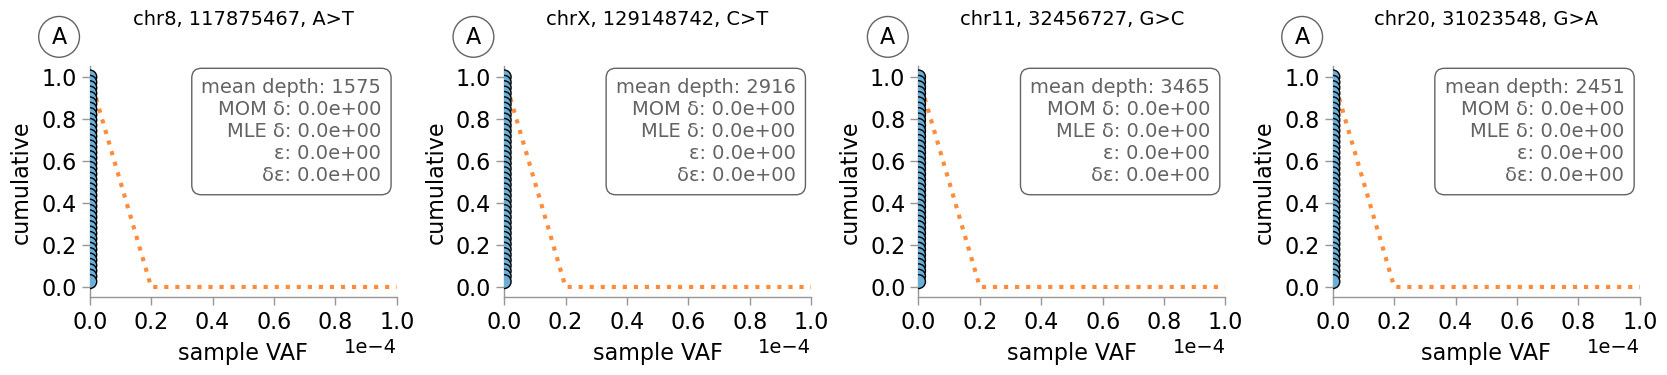

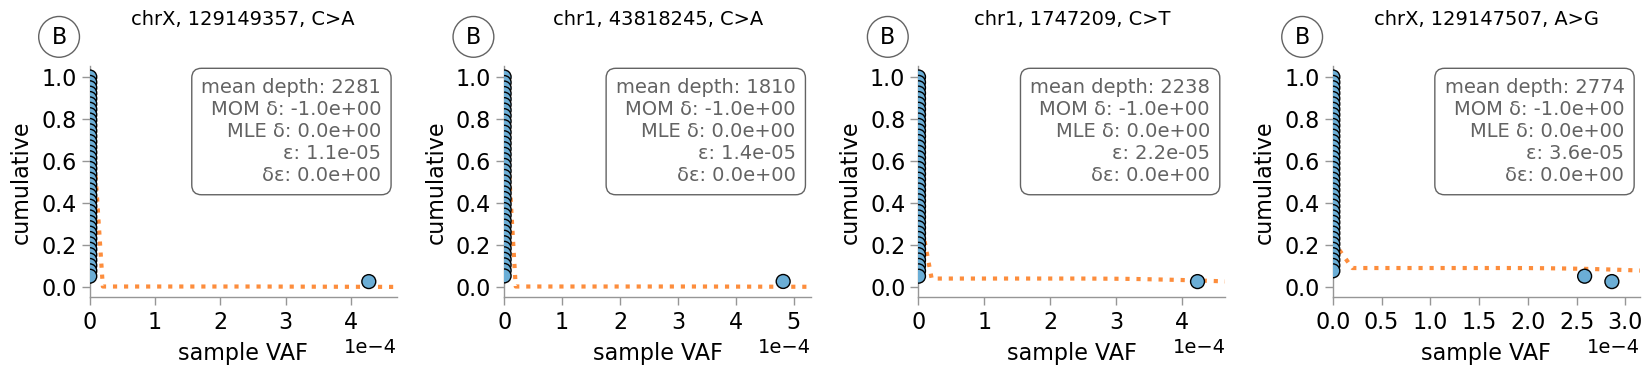

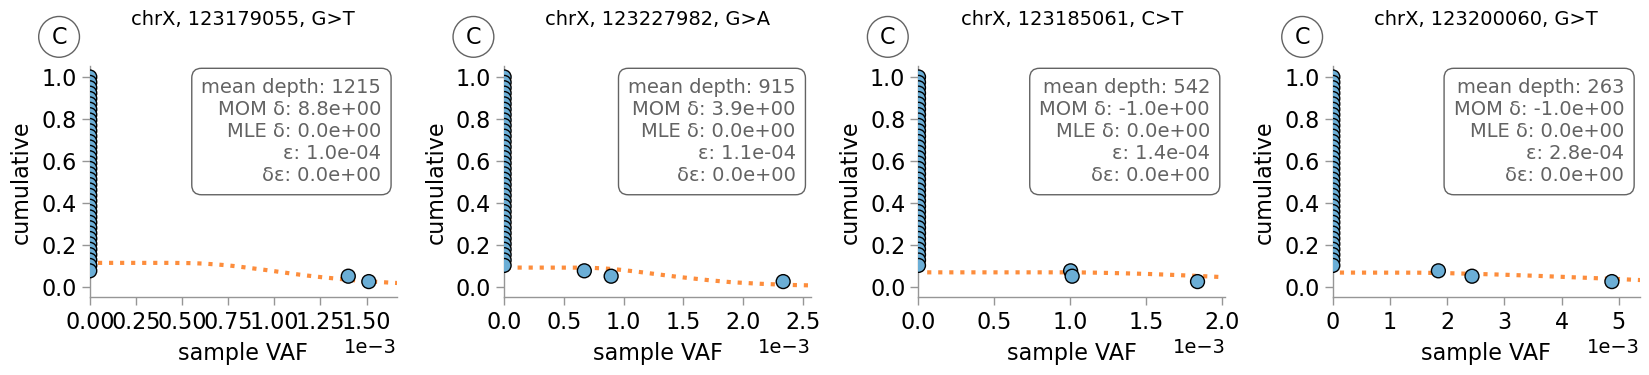

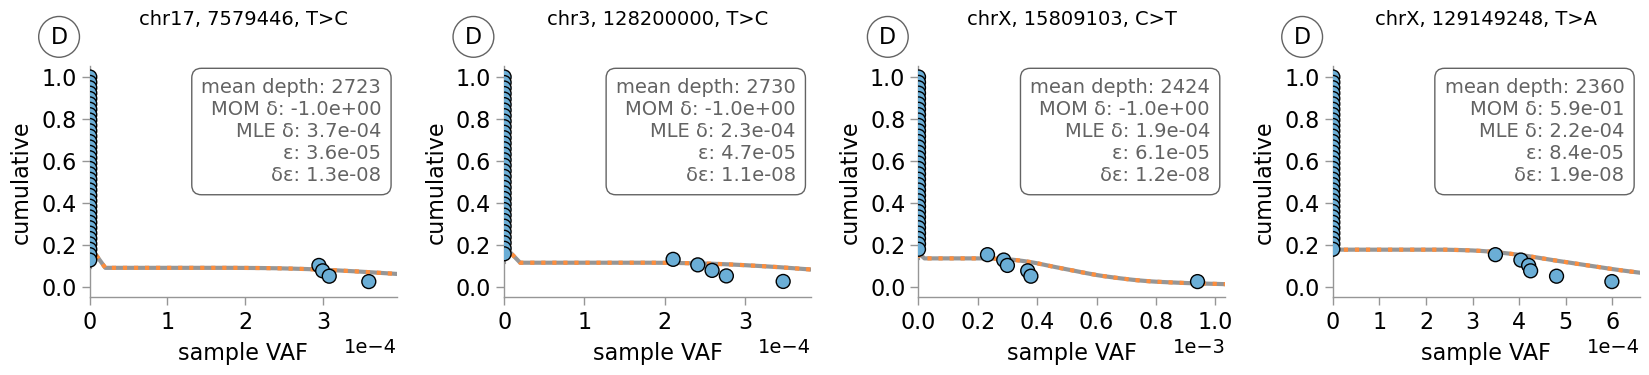

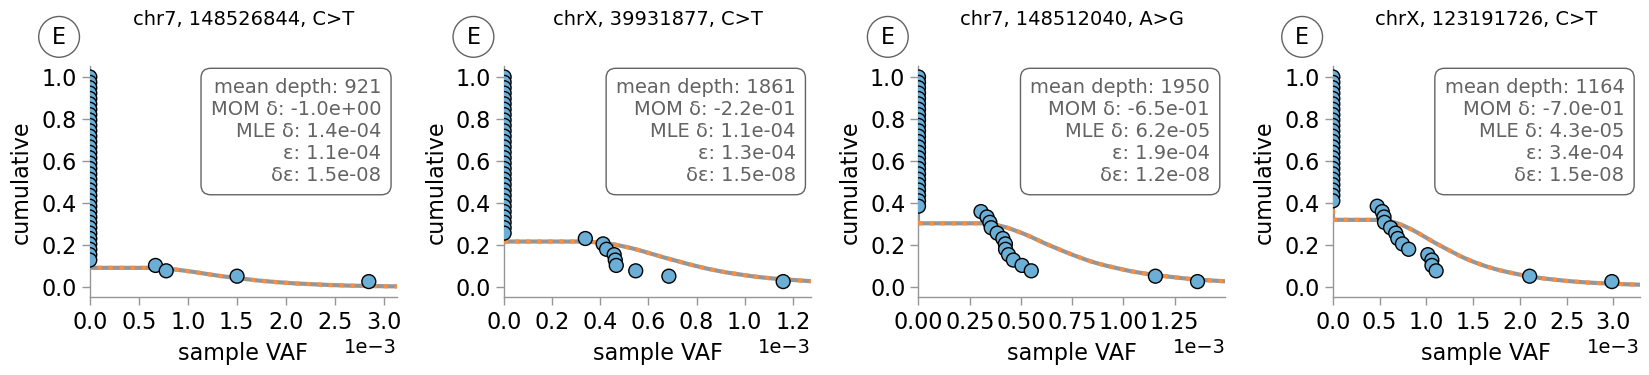

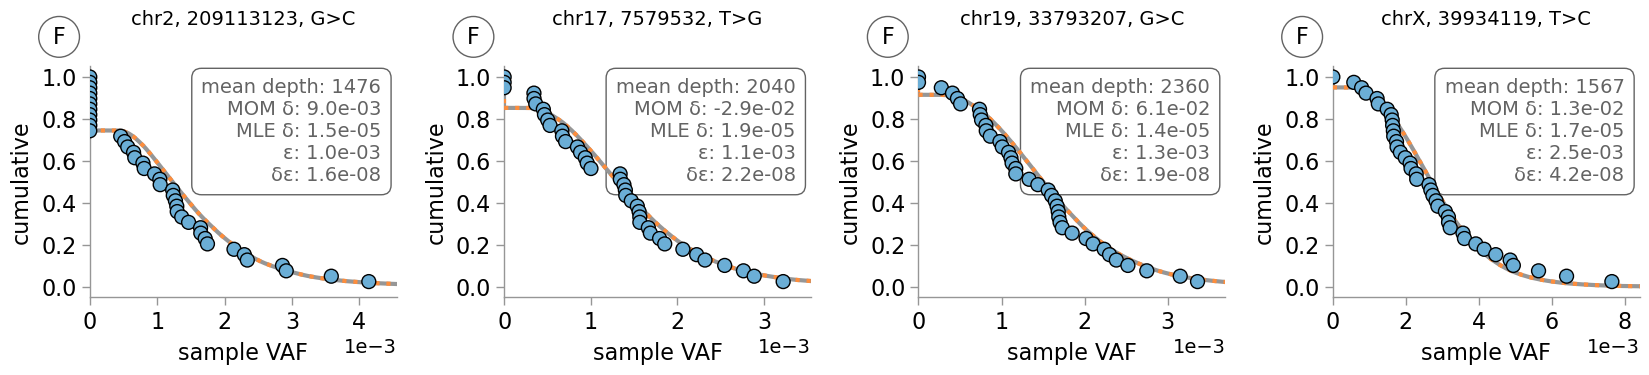

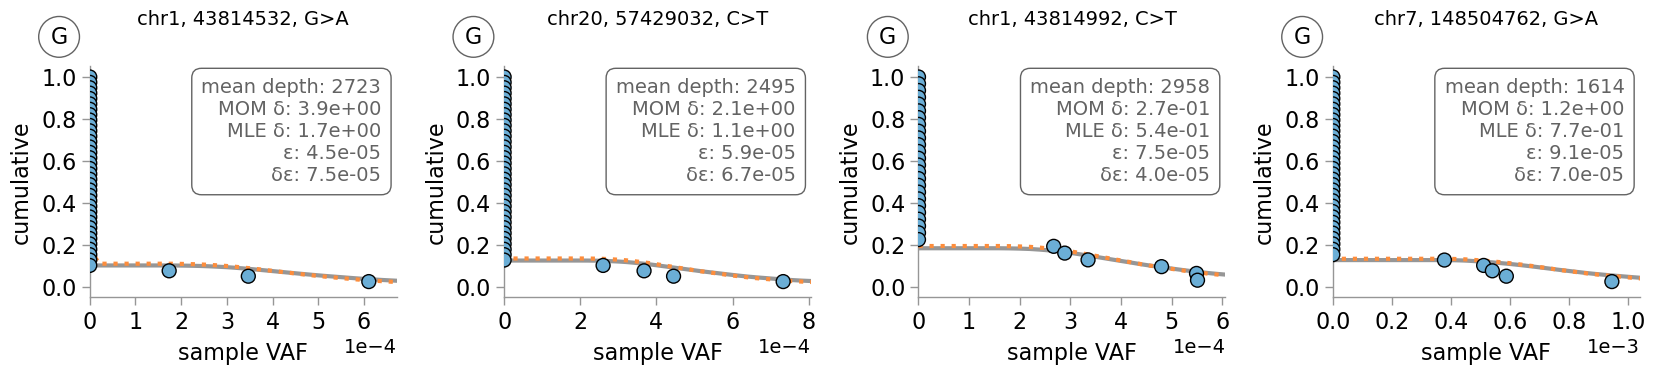

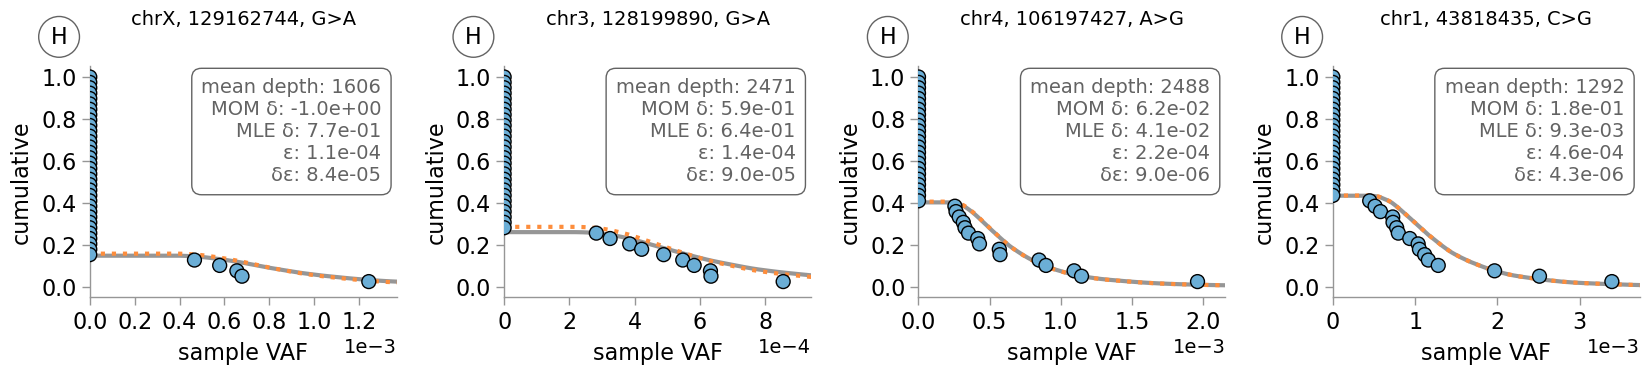

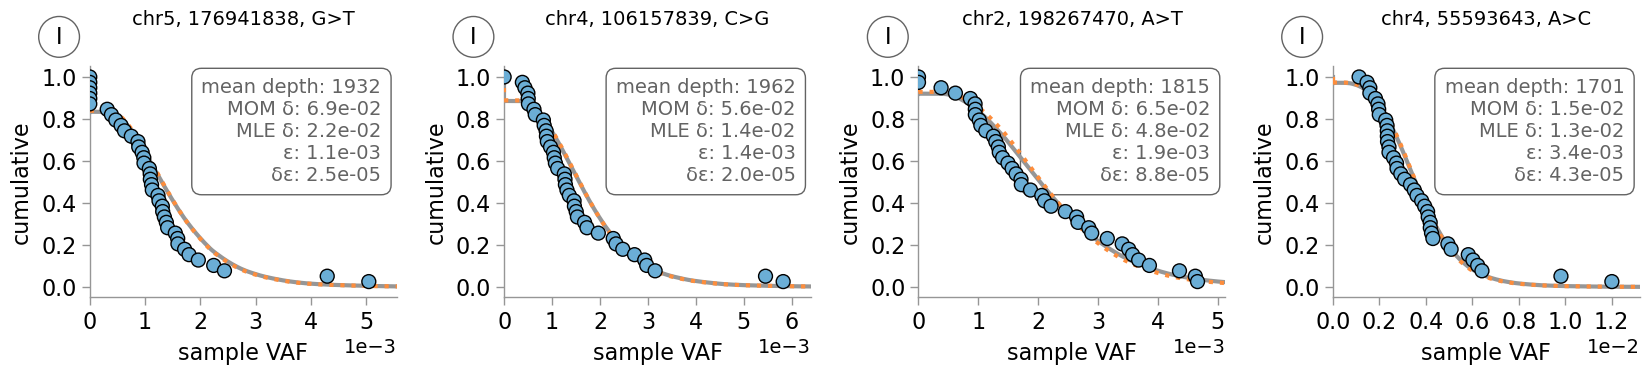

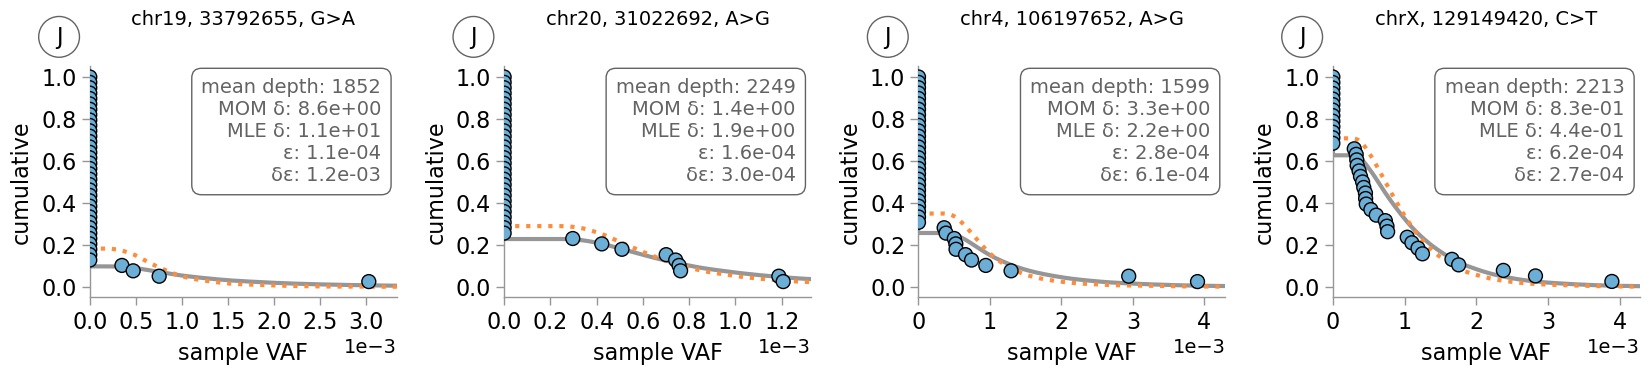

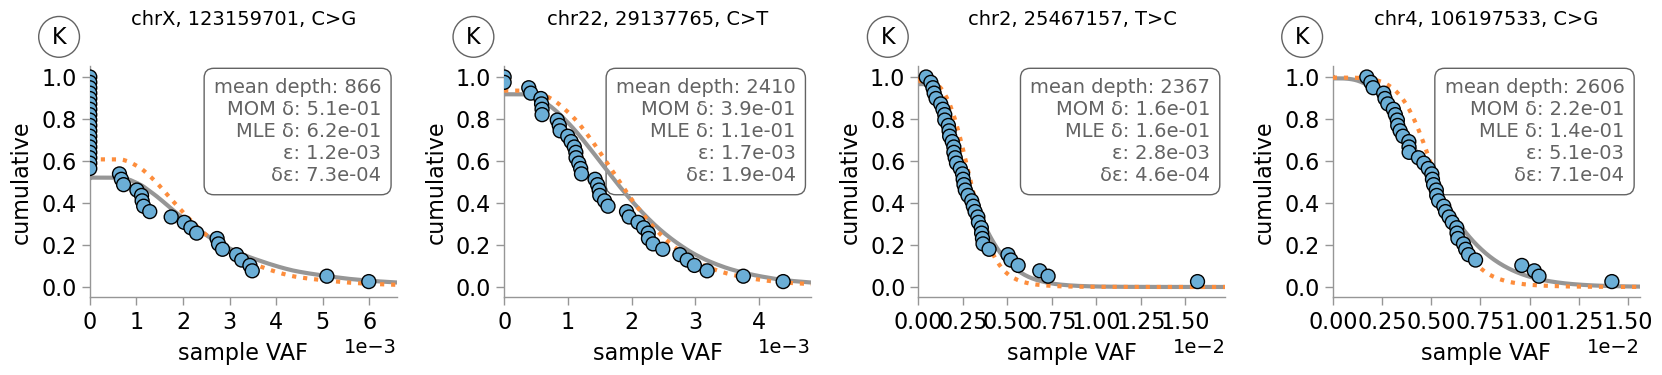

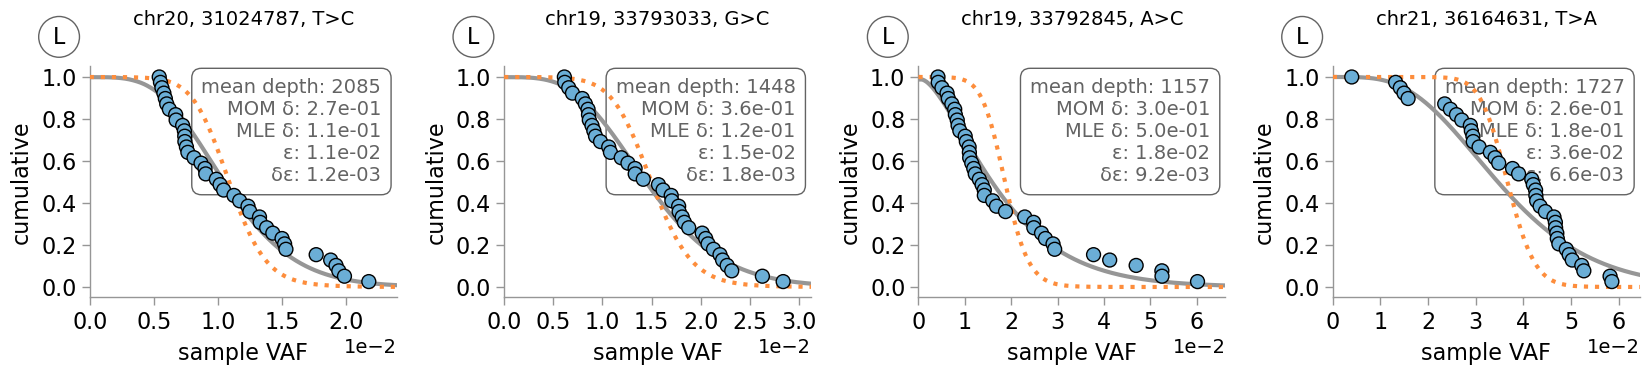

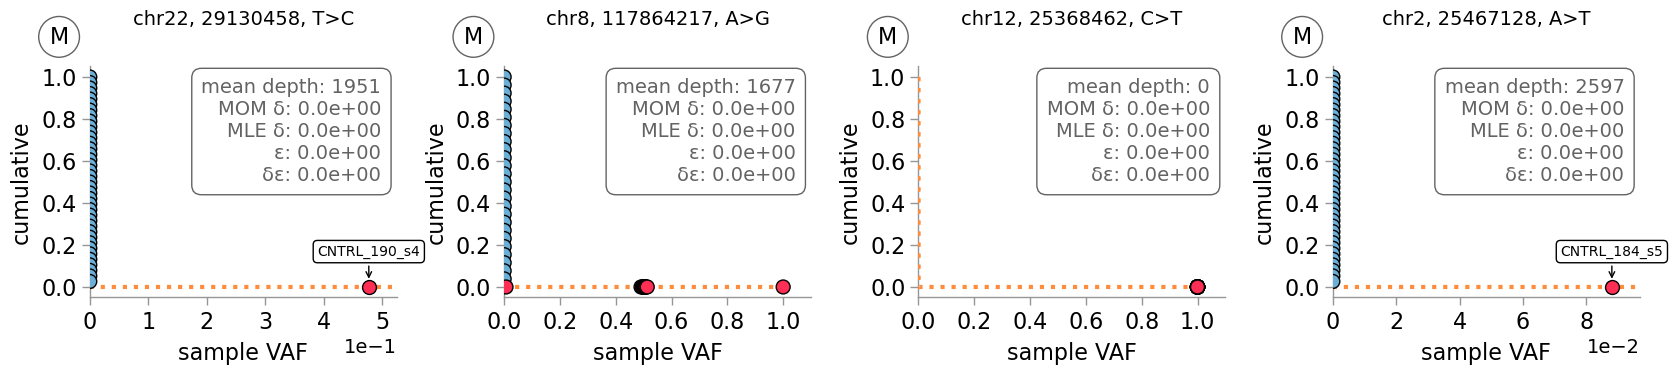

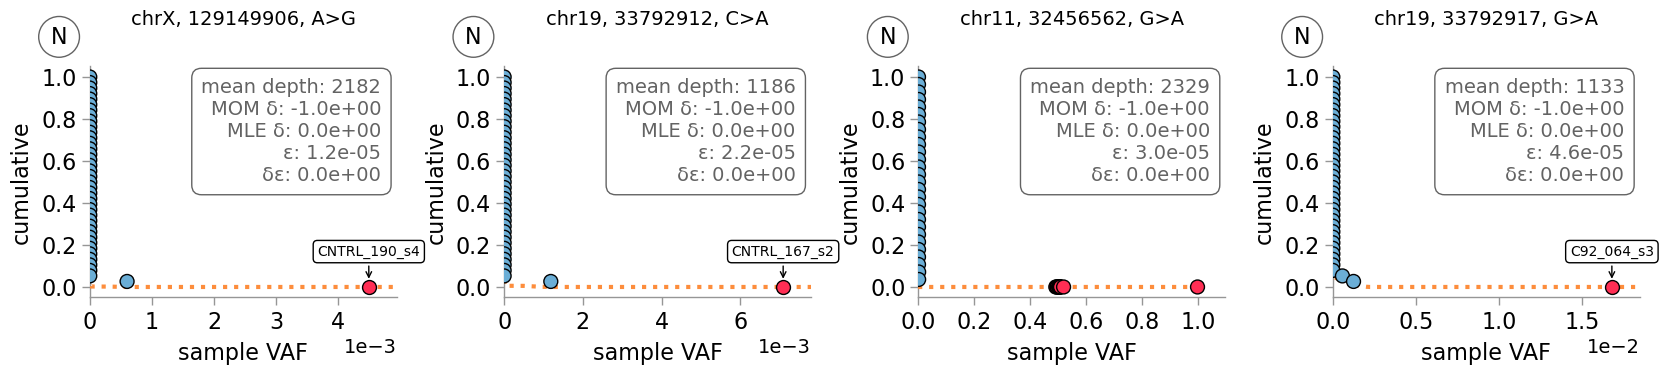

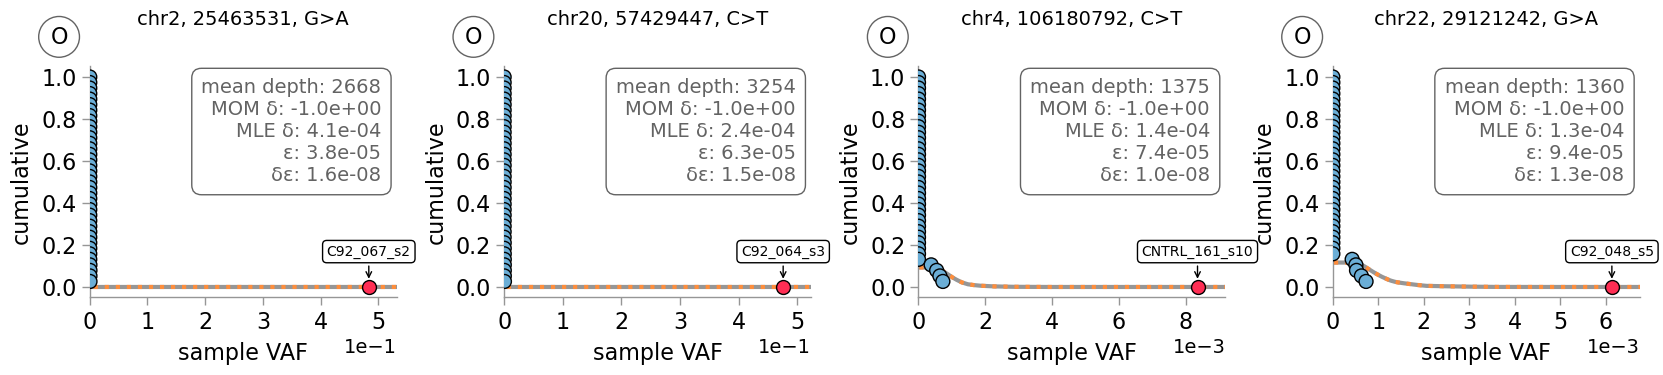

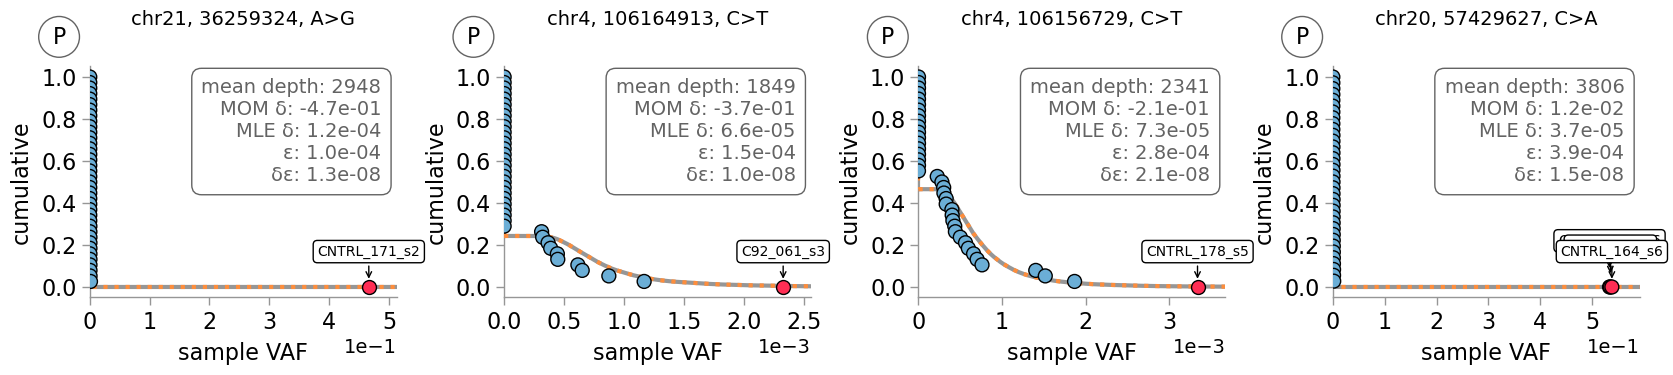

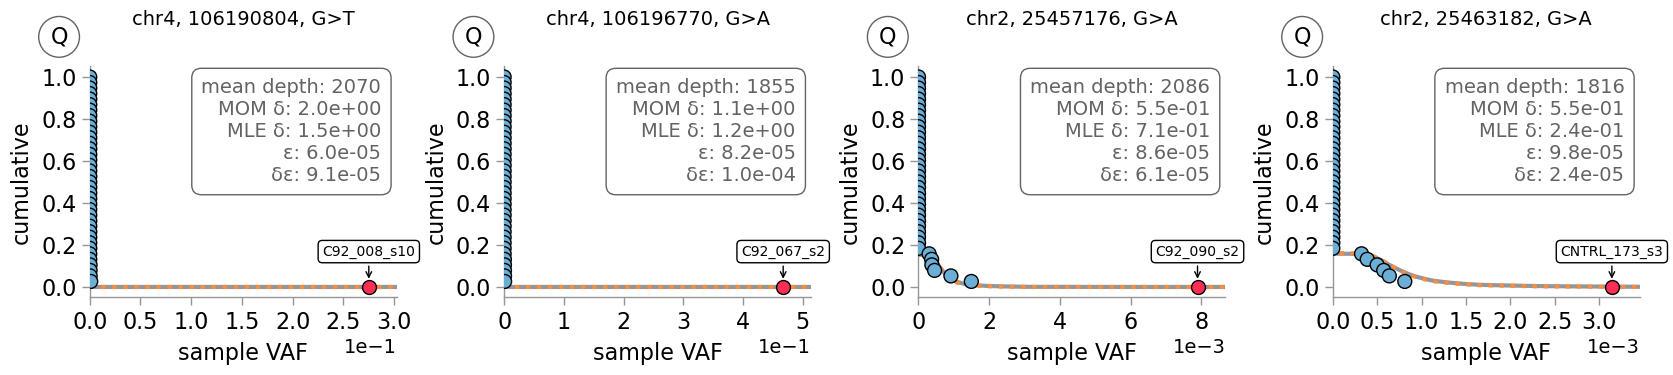

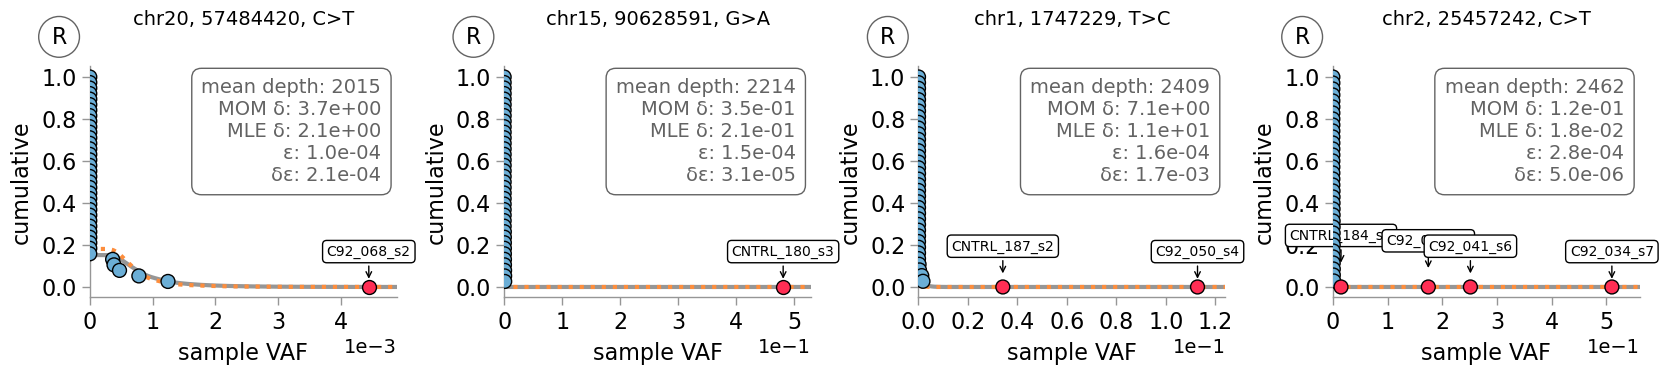

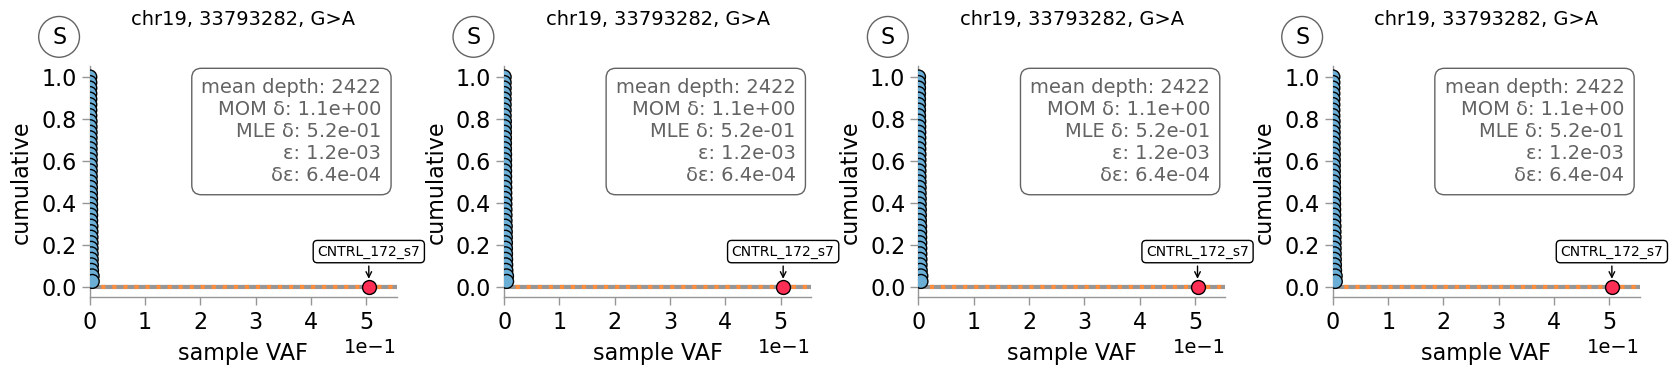

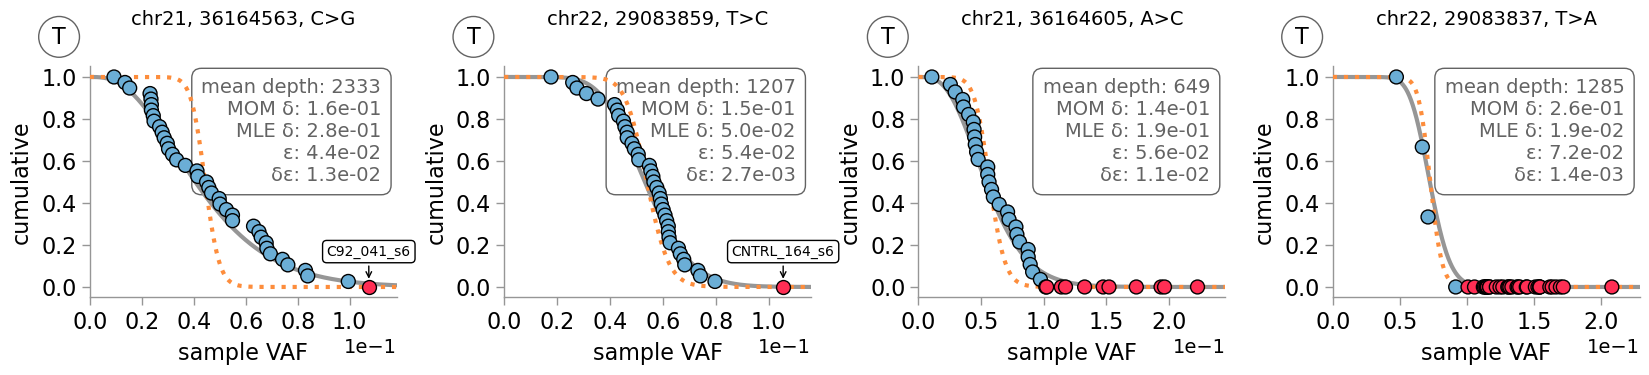

In [ ]:
cmap = 'viridis'
number_samples = 40

A_range = [np.nan, np.nan, 0, 0, 'A']
B_range = [np.nan, np.nan, 1e-5, 1e-4, 'B']
C_range = [np.nan, np.nan, 1e-4, 1e-3, 'C']
D_range = [1e-8, 1e-6, 1e-5, 1e-4, 'D']
E_range = [1e-8, 1e-6, 1e-4, 1e-3, 'E']
F_range = [1e-8, 1e-6, 1e-3, 1e-2, 'F']
G_range = [1e-6, 1e-4, 1e-5, 1e-4, 'G']
H_range = [1e-6, 1e-4, 1e-4, 1e-3, 'H']
I_range = [1e-6, 1e-4, 1e-3, 1e-2, 'I']
J_range = [1e-4, 1e-2, 1e-4, 1e-3, 'J']
K_range = [1e-4, 1e-2, 1e-3, 1e-2, 'K']
L_range = [1e-4, 1e-2, 1e-2, 1e-1, 'L']

M_range = [np.nan, np.nan, 0, 0, 'M']
N_range = [np.nan, np.nan, 1e-5, 1e-4, 'N']
O_range = [1e-8, 1e-6, 1e-5, 1e-4, 'O']
P_range = [1e-8, 1e-6, 1e-4, 1e-3, 'P']
Q_range = [1e-6, 1e-2, 1e-5, 1e-4, 'Q']
R_range = [1e-6, 1e-2, 1e-4, 1e-3, 'R']
S_range = [1e-4, 1e0, 1e-3, 1e-2, 'S']
T_range = [1e-4, 1e0, 1e-2, 1e-1, 'T']

no_variant_ranges = (A_range, B_range, C_range, D_range, E_range, F_range, G_range, H_range, I_range,
                    J_range, K_range, L_range)

variant_ranges = (M_range, N_range, O_range, P_range, Q_range, R_range, S_range, T_range)

all_positions_on_plot_no_variants = []
for letter in no_variant_ranges:
    print(letter)
    positions = plot_positions_dispersion_times_error_rate_actual_depths_VAFs(merged_MLE_DCS, 'DCS', letter[0], letter[1], letter[2], letter[3], 
                                                           letter[4], cmap, 0, number_samples, real_variants,
                                                                              'no_variants_called', MLEs, errors_p_values)
    all_positions_on_plot_no_variants.append(positions)
    
all_positions_on_plot_variants = []
for letter in variant_ranges:
    print(letter)
    positions = plot_positions_dispersion_times_error_rate_actual_depths_VAFs_exclude_real(merged_MLE_DCS, 'DCS', letter[0], letter[1], letter[2], letter[3], 
                                                           letter[4], cmap, 0, number_samples, real_variants,
                                                                              'variants_called', MLEs, errors_p_values)
    all_positions_on_plot_variants.append(positions)
    

## 5. The two ε-vs-δε scatter plots

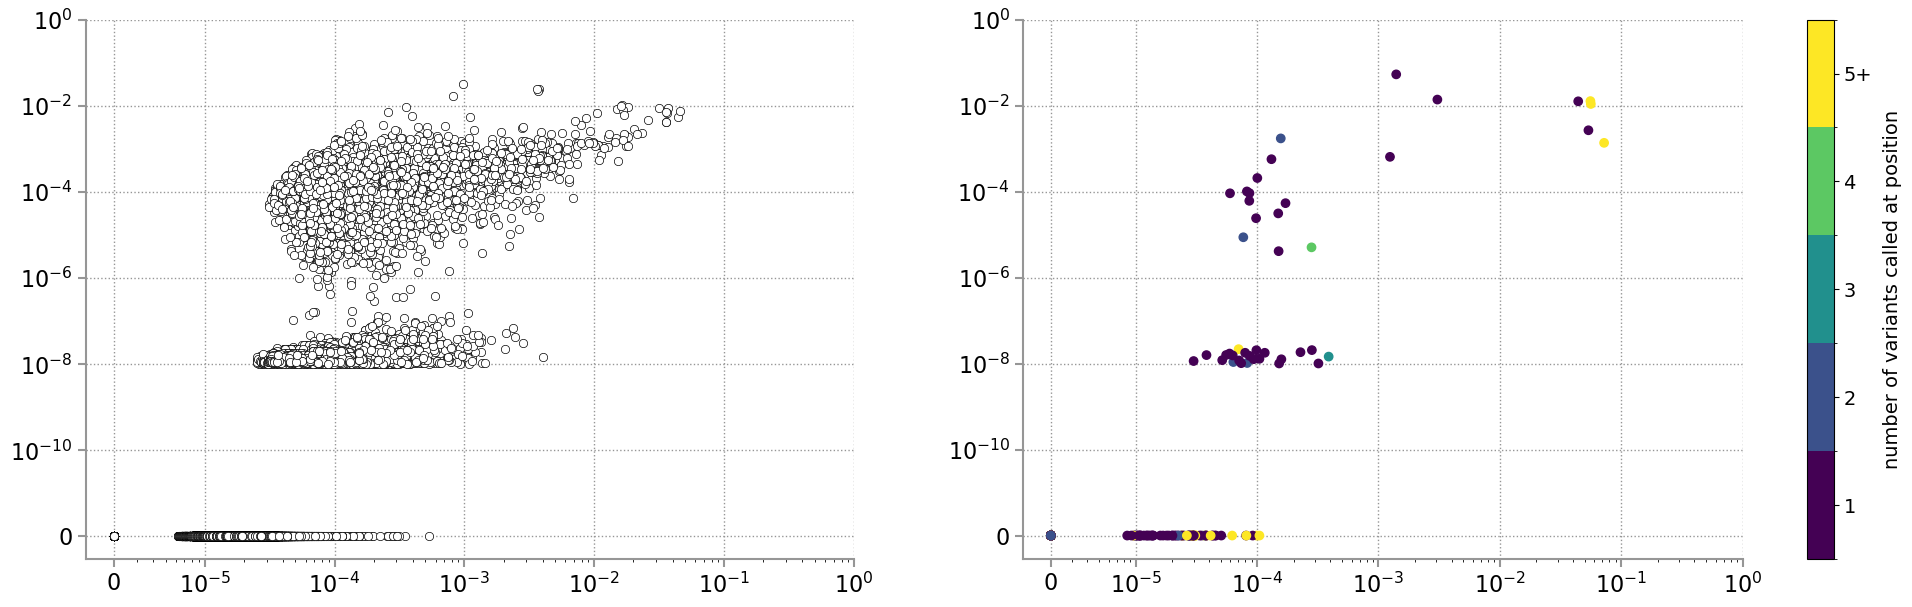

In [ ]:
# plot error rate by de
SSCS_or_DCS = 'DCS'

pseudo_epsilon_0 = 2e-6
pseudo_delta_epsilon_nan = 1e-12

x0 = []
y0 = []
x = []
y = []
colors = []
binomial = 0
zero_variants = 0
one_or_more_variants = 0

epsilon_0_no_variants = 0
epsilon_0_variants = 0

binomial_no_variants = 0
binomial_variants = 0

BB_binomial_no_variants = 0
BB_binomial_variants = 0

BB_no_variants =0
BB_variants =0

total_number_variants = []

for k, v in MLEs.items():
    number_variants = v['total variants called']
    epsilon = v['final position error rate']
    if '<' in str(epsilon):
        epsilon = 0
    else:
        epsilon = float(epsilon)
    delta = v['final delta']
    
    if epsilon == 0: #positions that are all 0 variant reads, either from the start or because after iterating there is only 1 non-zero variant read remaining
        epsilon = pseudo_epsilon_0
    
    if np.isnan(delta) == True: #if binomial was fitted, rather than beta-binomial
        delta_epsilon = pseudo_delta_epsilon_nan
        binomial+=1
    else:
        delta_epsilon = float(delta)*float(epsilon)
        
    total_number_variants.append(number_variants)
    
        
    if number_variants == 0:
        zero_variants += 1
        x0.append(epsilon)
        y0.append(delta_epsilon)
        
        if delta_epsilon > 1e-6:
            BB_no_variants +=1
        if 1e-10 < delta_epsilon <1e-6:
            BB_binomial_no_variants +=1
        if delta_epsilon < 1e-10:
            if epsilon == pseudo_epsilon_0:
                epsilon_0_no_variants +=1
            else:
                binomial_no_variants +=1
        
    if number_variants > 0:
        one_or_more_variants+=1
        x.append(epsilon)
        y.append(delta_epsilon)
        if number_variants >=5:
            number_variants = 5
        colors.append(number_variants)
        
        if delta_epsilon > 1e-6:
            BB_variants +=1
        if 1e-10 <delta_epsilon <1e-6:
            BB_binomial_variants +=1
        if delta_epsilon < 1e-10:
            if epsilon == pseudo_epsilon_0:
                epsilon_0_variants +=1
            else:
                binomial_variants +=1
            
print('max number of variants at a position = ', max(total_number_variants))
            
print('binomial no variants = ', binomial_no_variants)
print('binomial variants = ', binomial_variants)
print('epsilon 0 no variants = ', epsilon_0_no_variants)
print('epsilon 0 variants = ', epsilon_0_variants)
print('BB binomial no variants = ', BB_binomial_no_variants)
print('BB binomial variants = ', BB_binomial_variants)
print('BB no variants = ', BB_no_variants)
print('BB variants = ', BB_variants)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (24, 7), gridspec_kw={'width_ratios': [1, 1.2]})

plot0 = ax1.scatter(x0, y0, color = 'white', edgecolor = 'k', lw = 0.5, zorder = 50)

bounds = np.array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5])
plot1 = ax2.scatter(x, y, c = colors, cmap='viridis', norm = matplotlib.colors.BoundaryNorm(boundaries=bounds, ncolors=256), zorder = 50)
# plot1 = ax2.scatter(x, y, c = colors, cmap='Set1', norm = matplotlib.colors.BoundaryNorm(boundaries=bounds, ncolors=256))

cbar = fig.colorbar(plot1, ax = ax2, pad=0.07, ticks=[1, 2, 3, 4, 5])
cbar.set_label('number of variants called at position', rotation=90, fontsize = 14, labelpad=8)
cbar.ax.tick_params(labelsize=14) 
cbar.ax.set_yticklabels(['1', '2', '3', '4', '5+'])  # vertically oriented colorbar

for ax in [ax1, ax2]:
#     ax.set_xlabel('position error rate (\u03B5)', fontsize = 16, labelpad = 12, fontweight = 'medium')
#     ax.set_ylabel('dispersion x error rate (\u03B4\u03B5)', fontsize = 16, labelpad = 12, fontweight = 'medium')

    ax.xaxis.set_tick_params(width=1.5, color = grey3, length = 6)
    ax.yaxis.set_tick_params(width=1.5, color = grey3, length = 6)

    for item in (ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontsize(16)

    #Only show the required axis lines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1.5)
        ax.spines[axis].set_color(grey3)
        
    ax.set_yscale('log')
    ax.set_xscale('log')
    
    ax.set_xticks([pseudo_epsilon_0, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1e0])
    ax.set_xticklabels(['0', '$10^{-5}$', '$10^{-4}$', '$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$10^{0}$'])
    
    ax.set_yticks([pseudo_delta_epsilon_nan, 1e-10, 1e-8, 1e-6, 1e-4, 1e-2, 1e0])
    ax.set_yticklabels(['0', '$10^{-10}$', '$10^{-8}$', '$10^{-6}$', '$10^{-4}$', '$10^{-2}$', '$10^{0}$'])
    
    ax.grid(which = 'major', color = grey3, lw = 1, linestyle=':', zorder = 0)

plt.show()